In [1]:
import kagglehub
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import re
import html
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, 
    recall_score, confusion_matrix,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import spearmanr

# Steam Games Dataset - data analysis and hit prediction

## Overview

This notebook presents data analysis and classification using ML models based on the Steam Games Dataset (~122,000 games, 39 features).

The main question here is: can we predict whether a game will be a hit? We define a "hit" as a game with at least 1,000 positive reviews and a positive rating of 80% or above.

## Dataset download

In [2]:
path = kagglehub.dataset_download("fronkongames/steam-games-dataset")
print(f'Dataset saved as {shutil.copy(f"{path}/games.csv", "./games.csv")}')

Dataset saved as ./games.csv


## Data exploration

In [3]:
df = pd.read_csv('games.csv')
pd.set_option('display.max_columns', None)

In [4]:
pd.set_option('display.max_colwidth', 50)
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


### Cleaning

First problem that I have noticed, is the shift in the names of the first few columns. It seems that the problematic column is "DiscountDLC count". I believe that this header should be split into two separated columns and the column names to the left should be shifted one position to the left. I will correct this accordingly.

In [5]:
df.keys()

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='object')

In [6]:
df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

In [7]:
df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


### Missing values and data types

In this section, I examine the dataset's structure, including data types and missing values and identify columns that require parsing or type conversion in. I also decide how to handle incomplete, inconsistent, or redundant data before proceeding with the analysis.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        122610 non-null  object 
 1   Release date                122611 non-null  object 
 2   Estimated owners            122611 non-null  object 
 3   Peak CCU                    122611 non-null  int64  
 4   Required age                122611 non-null  int64  
 5   Price                       122611 non-null  float64
 6   Discount                    122611 non-null  int64  
 7   DLC count                   122611 non-null  int64  
 8   About the game              114162 non-null  object 
 9   Supported languages         122611 non-null  object 
 10  Full audio languages        122611 non-null  object 
 11  Reviews                     12070 non-null   object 
 12  Header image                122530 non-null  object 
 13  Website     

In [9]:
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing': df.isna().sum().values,
    'Percentage': (df.isna().sum() / len(df) * 100).round(2).values
}).sort_values('Percentage', ascending=False).reset_index(drop=True)

missing[missing['Missing'] > 0]

,Column,Missing,Percentage
0,Movies,122611,100.00
1,Score rank,122571,99.97
2,Metacritic url,118355,96.53
3,Reviews,110541,90.16
4,Notes,100153,81.68
5,Website,72935,59.48
6,Support url,68469,55.84
7,Tags,39265,32.02
8,Support email,22263,18.16
9,Categories,8953,7.30


There is one game that has no name and also NaNs in most of other columns- it should be romoved, because its probably some error in data.

In [10]:
df = df[df['Name'].notna()]

In [11]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 50)

df.loc[df['Notes'].notna() & (df['Required age'] == 0), ['Notes', 'Required age']]

,Notes,Required age
3292190,The game includes the following elements. 1. G...,0
1654170,The trailer and the screenshots may contain co...,0
2922740,"gore,blood",0
1282900,"Game contains nudity, uncensored genitalia and...",0
2403000,"The game contains Nudity or Sexual Content, Al...",0
...,...,...
4204040,- Nudity - Strong sexual content,0
4249780,Violence is present through the act of killing...,0
4182060,Blood will appear when enemies or zombies are ...,0
4153410,All characters depicted in this game are 18 ye...,0


"Movies" column has no non-null values - it should be dropped, because it gives us no information. Same about "Score rank"- almost 100% of examples has no value in this column. 

I will also drop "Notes" column- 80% of values is missing and it's a descriptive column, so it would have to inspected by NLP or manually first. And actually most of the notes say about some explicit content in the game, which logically would correspond with column "Required age"- but in most cases it does not. This relationship is inconsistent and unreliable, making the feature even less useful for modeling.

In [12]:
df.drop(columns=["Movies", "Score rank", "Notes"], inplace=True)

Later we are going to predict "is_hit" target, which is based on colums "Positive" and "Negative". Therefore we do not need columns that inform us about latest number of players and their playtime. So I will drop columns "Peak CCU", "Average playtime two weeks" and "Median playtime two weeks".

In [13]:
df.drop(columns=["Peak CCU", "Average playtime two weeks", "Median playtime two weeks"], inplace=True)

I have also noticed, that columns "Metacritic score" and Metaciritic url" may be redundant. Dataset description says: 
- Metacritic score, 0 if it has none (int).
- Metacritic review URL (string).

Let's check whether there are any examples, where url is present and score is == 0 and where url is absent and score is != 0.

In [14]:
no_url = df['Metacritic url'].isna()

url_score0_count = (~no_url & (df['Metacritic score'] == 0)).sum()
no_url_score_not0_count = (no_url & (df['Metacritic score'] != 0)).sum()

print(f"Games with Metacritic url and score 0: {url_score0_count}")
print(f"Games without Metacritic url and score not 0: {no_url_score_not0_count}")

Games with Metacritic url and score 0: 0
Games without Metacritic url and score not 0: 0


As I have expected, there are no such examples. In that case we can drop column "Metacritic URL", because it gives us no additional information.

In [15]:
df.drop(columns="Metacritic url", inplace=True)

Let's also change the 'Release date' format from obejct to datetime.

In [16]:
df['Release date'] = pd.to_datetime(df['Release date'], format='%b %d, %Y', errors='coerce')

Now I will take a look at other desriptive columns that have missing values.

In [17]:
pd.set_option('display.max_colwidth', None)
df[df['Reviews'].notna()]['Reviews']

1025440    “And this is the very reason why I believe Fantasy General 2: Invasion has not only tremendous staying power, but the potential of a fulfilling future.” 9 – Turn Based Lovers “Graphically, I found the game beautiful, the music even great (the main track has been remastered from the original). The dialogue text and story depth is completely sufficient for me. Even though the balance of the game is not perfect and the level of difficulty is so high that it just cannot be done without reloading and optimizing, I still recommend any lover of turn-based games to buy it. Otherwise, you'll miss one of the most challenging and gripping genre representatives of the year!” 9.0 – Gamersglobal “Like its predecessor, Fantasy General 2 captivates from the first mission and even improves a lot of things from the original: The moral system is more transparent, the missions with their very different goals and many side locations are much more dynamic. I am moved to try everything to prevent 

I will replace column "Reviews" with a boolean flag 'has_reviews'. One could theoretically perform sentiment analysis here and derive features such as 'has_positive_review' or 'has_negative_review', however this field is only populated for ~10% of games. Applying NLP on such incomplete data could introduce more noise than value. And presence of review already gives us signal, that the game was notable enough to receive a review.

Columns such as "Support email" or "Website" will also be replaced with boolean flags, because their exact value does not really concern us, just their presence.

In [18]:
df['has_support_email'] = df['Support email'].notna().astype(int)
df['has_support_url']   = df['Support url'].notna().astype(int)
df['has_website']       = df['Website'].notna().astype(int)
df['has_reviews']       = df['Reviews'].notna().astype(int)
df['has_header_image'] = df['Header image'].notna().astype(int)
df['Screenshots_count'] = df['Screenshots'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)

cols_to_drop = ['Support email', 'Support url', 'Website', 'Reviews', 'Header image', 'Screenshots']
df.drop(columns=cols_to_drop, inplace=True)

Now let's analyze "Developers" and "Publishers" columns.

In [19]:
print(df['Developers'].unique().shape[0])
print(df['Publishers'].unique().shape[0])

70813
62685


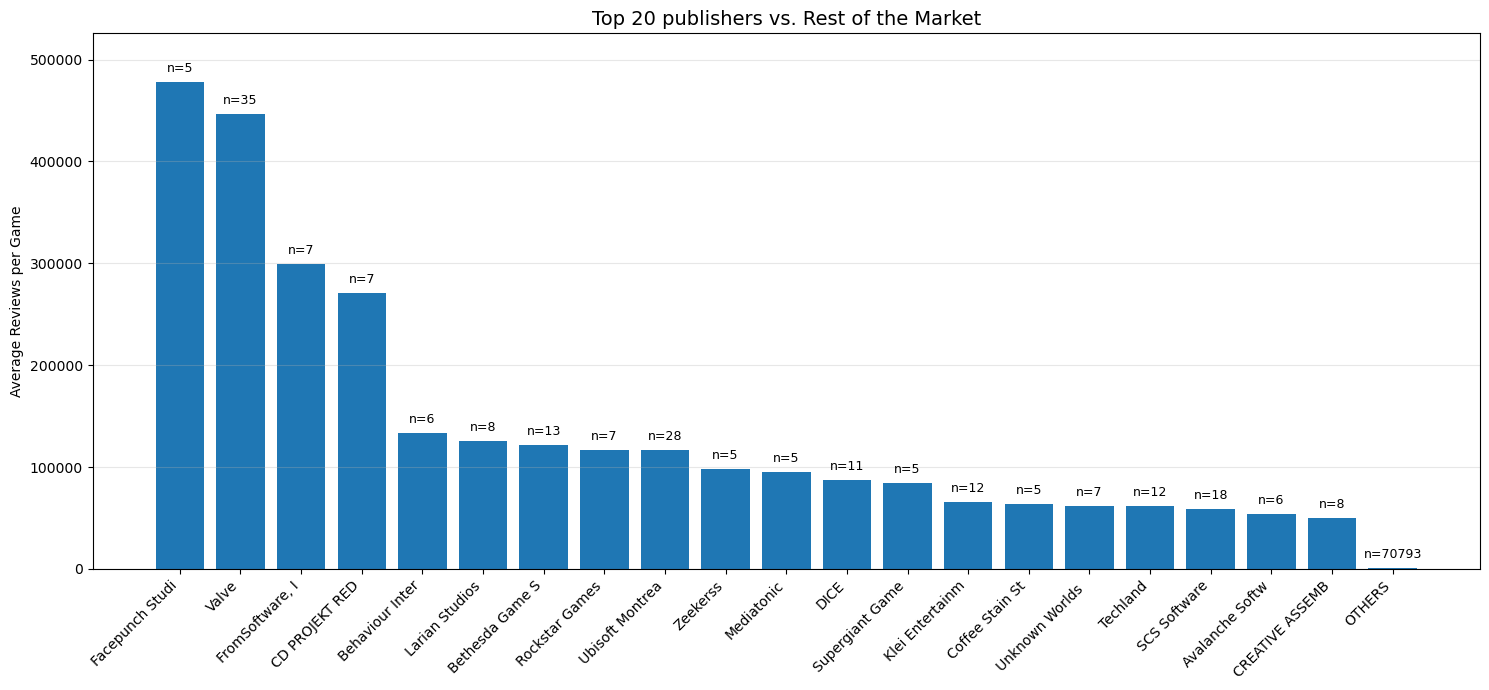

In [20]:
total_reviews = df['Positive'] + df['Negative']

temp_publishers = df['Developers'].fillna('Unknown')
pub_stats = pd.DataFrame({
    'reviews': total_reviews,
    'publisher': temp_publishers
}).groupby('publisher').agg(['mean', 'count'])['reviews']

top_20 = pub_stats[pub_stats['count'] >= 5].sort_values(by='mean', ascending=False).head(20)
others_count = temp_publishers[~temp_publishers.isin(top_20.index)].nunique()
others_mean = total_reviews[~temp_publishers.isin(top_20.index)].mean()

fig, ax = plt.subplots(figsize=(15, 7))

labels = [str(n)[:15] for n in top_20.index] + ['OTHERS']
values = list(top_20['mean']) + [others_mean]
counts = list(top_20['count']) + [others_count]

bars = ax.bar(labels, values)

ax.bar_label(bars, labels=[f'n={c}' for c in counts], padding=5, fontsize=9)

ax.set_title('Top 20 publishers vs. Rest of the Market', fontsize=14)
ax.set_ylabel('Average Reviews per Game')
ax.set_ylim(0, max(values) * 1.1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

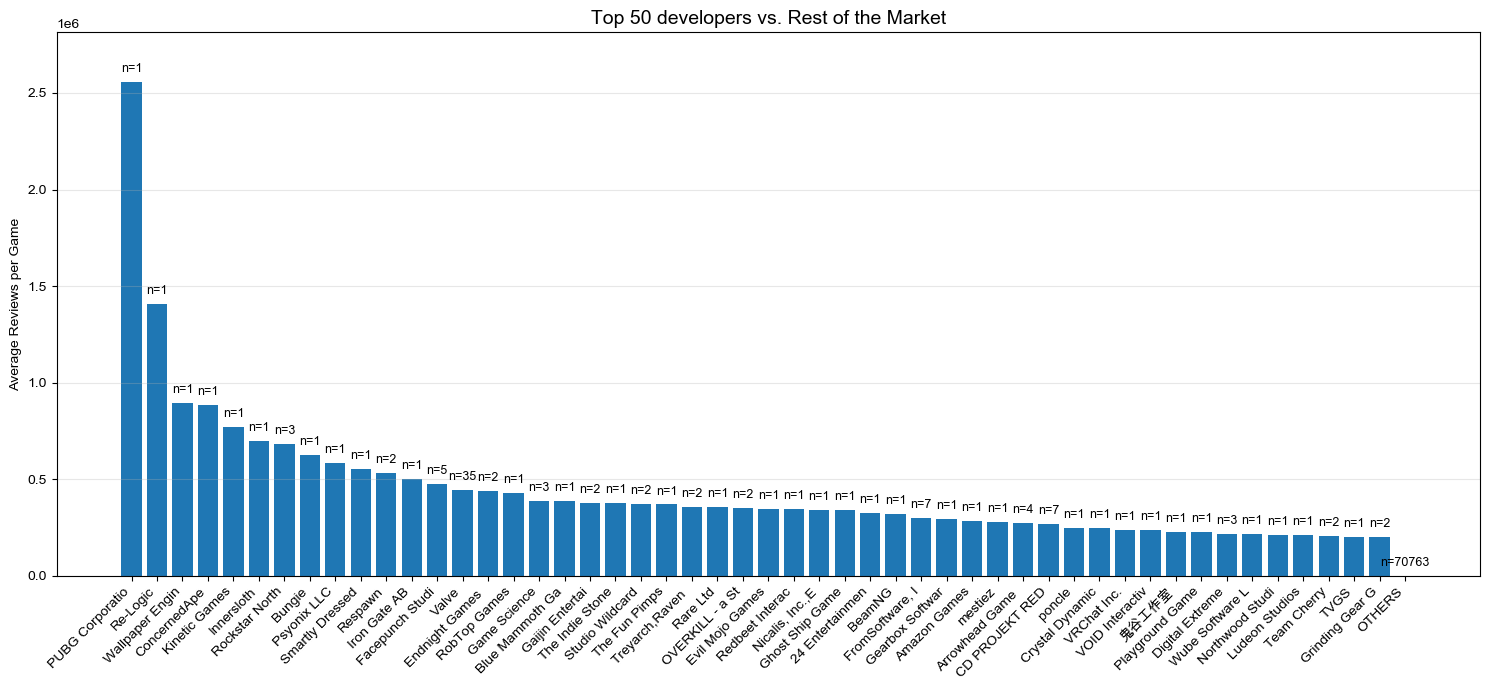

In [22]:
temp_developers = df['Developers'].fillna('Unknown')
pub_stats = pd.DataFrame({
    'reviews': total_reviews,
    'publisher': temp_developers
}).groupby('publisher').agg(['mean', 'count'])['reviews']

top_50 = pub_stats[pub_stats['count'] >= 1].sort_values(by='mean', ascending=False).head(50)
others_count = temp_developers[~temp_developers.isin(top_50.index)].nunique()
others_mean = total_reviews[~temp_developers.isin(top_50.index)].mean()

fig, ax = plt.subplots(figsize=(15, 7))

labels = [str(n)[:15] for n in top_50.index] + ['OTHERS']
values = list(top_50['mean']) + [others_mean]
counts = list(top_50['count']) + [others_count]

bars = ax.bar(labels, values)

ax.bar_label(bars, labels=[f'n={c}' for c in counts], padding=5, fontsize=9)

ax.set_title('Top 50 developers vs. Rest of the Market', fontsize=14)
ax.set_ylabel('Average Reviews per Game')
ax.set_ylim(0, max(values) * 1.1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False

plt.show()

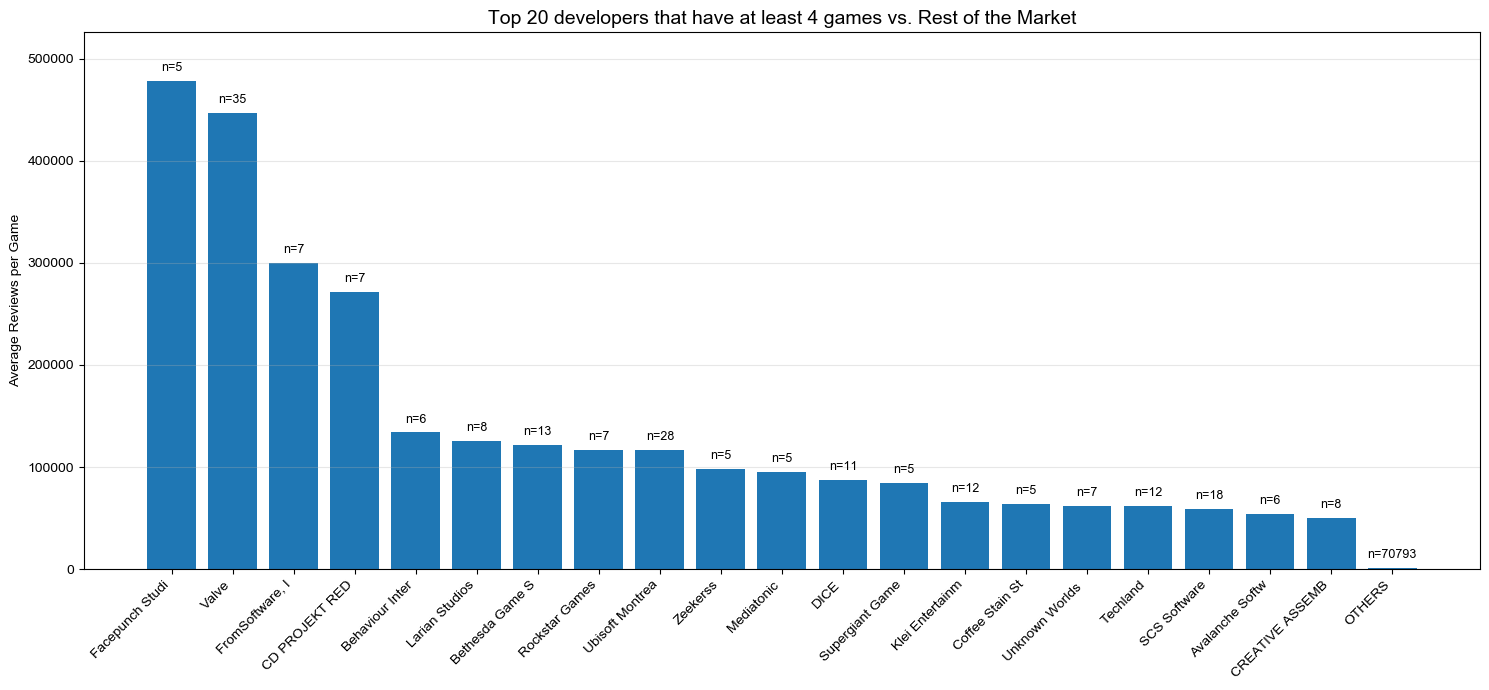

In [23]:
top_20 = pub_stats[pub_stats['count'] >= 5].sort_values(by='mean', ascending=False).head(20)
others_count = temp_developers[~temp_developers.isin(top_20.index)].nunique()
others_mean = total_reviews[~temp_developers.isin(top_20.index)].mean()

fig, ax = plt.subplots(figsize=(15, 7))

labels = [str(n)[:15] for n in top_20.index] + ['OTHERS']
values = list(top_20['mean']) + [others_mean]
counts = list(top_20['count']) + [others_count]

bars = ax.bar(labels, values)

ax.bar_label(bars, labels=[f'n={c}' for c in counts], padding=5, fontsize=9)

ax.set_title('Top 20 developers that have at least 4 games vs. Rest of the Market', fontsize=14)
ax.set_ylabel('Average Reviews per Game')
ax.set_ylim(0, max(values) * 1.1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

We can see that there are two developers with only one game each, but an exceptionally high number of reviews- PUBG Corporation and Re-Logic. Due to their disproportionate influence on review-based metrics, I will treat them as outliers and remove them from the dataset.

In [24]:
df = df[~df['Developers'].isin(['PUBG Corporation', 'Re-Logic'])]

Now let's leave just top 20 developers- those, who have the highest number of positive reviews. Same with publishers.

In [25]:
dev_score = df.groupby('Developers')['Positive'].sum()

top_developers = dev_score.nlargest(50).index.tolist()
df['is_top_developer'] = df['Developers'].apply(lambda x: 1 if x in top_developers else 0)
df.drop(columns=['Developers'], inplace=True)

In [26]:
pub_score = df.groupby('Publishers')['Positive'].sum()
top_publishers = pub_score.nlargest(50).index.tolist()
df['is_top_publisher'] = df['Publishers'].apply(lambda x: 1 if x in top_publishers else 0)
df.drop(columns=['Publishers'], inplace=True)

Tags, categories, genres seem quite similar, so I will analyze them together.

In [27]:
# Tags, categories, genres
print("Categories:", df["Categories"].unique(), len(df["Categories"].unique()), "\n")
print("Genres:", df["Genres"].unique(), len(df["Genres"].unique()), "\n")
print("Tags:", df["Tags"].unique(), len(df["Tags"].unique()), "\n")

Categories: [nan 'Single-player,Steam Trading Cards,Steam Cloud,Family Sharing'
 'Single-player,Family Sharing' ...
 'Single-player,Steam Achievements,Color Alternatives,Custom Volume Controls,Keyboard Only Option,Playable without Timed Input,Stereo Sound,Steam Cloud,Family Sharing'
 'Single-player,Multi-player,Co-op,Online Co-op,Adjustable Difficulty,Playable without Timed Input,Stereo Sound,Family Sharing'
 'Single-player,Multi-player,PvP,Online PvP,Co-op,Online Co-op,Steam Achievements,Playable without Timed Input,Stereo Sound,Stats,Family Sharing'] 13291 

Genres: [nan 'Adventure' 'Casual' ...
 'Action,Casual,RPG,Simulation,Sports,Strategy,Early Access'
 'Action,Adventure,Casual,Racing,RPG,Sports'
 'Action,Indie,RPG,Simulation,Strategy,Free To Play'] 2895 

Tags: [nan 'Adventure,Visual Novel,Anime,Cute'
 'Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop'
 ...
 'Horror,Puzzle,Survival Ho

There is a lot of different categories, genres and tags. I can see that some values are the same in Genres and Tags. That's why I think it will be a good idea to impute missing Genres values with Tags. Genres seem to be more reliable, but when the value there is missing, Tags may help. I will also put the categories and genres into bigger groups- meta genres/categories, because some of the values have nearly identical meanings, yet they are currently treated as different categories/genres.

In [28]:
def split_tags(x):
    if pd.isna(x):
        return []
    return [t.strip() for t in str(x).split(',')]

df['Categories'] = df['Categories'].apply(split_tags)
df['Genres'] = df['Genres'].apply(split_tags)
df['Tags'] = df['Tags'].apply(split_tags)

In [29]:
def impute_genres(row):
    if not row['Genres']:
        return row['Tags']
    return row['Genres']

df['Genres'] = df.apply(impute_genres, axis=1)

In [30]:
def apply_manual_category_mapping(df):
    category_mapping = {
        'has_multiplayer': ['Multi-player', 'Online PvP', 'Online Co-op', 'Cross-Platform Multiplayer', 'MMO', 'PvP', 'Co-op'],
        'has_local_multi': ['Shared/Split Screen', 'Shared/Split Screen Co-op', 'Shared/Split Screen PvP', 'LAN Co-op', 'LAN PvP', 'Remote Play Together'],
        'has_workshop': ['Steam Workshop', 'Includes level editor', 'Mods', 'Mods (require HL2)'],
        'has_achievements': ['Steam Achievements', 'Steam Trading Cards', 'Steam Leaderboards'],
        'has_controller_support': ['Full controller support', 'Partial Controller Support'],
        'has_cloud_saves': ['Steam Cloud'],
        'has_vr': ['VR Support', 'VR Supported', 'VR Only'],
        'has_accessibility_opts': ['Subtitle Options', 'Captions available', 'Adjustable Text Size', 'Color Alternatives', 'Custom Volume Controls', 'Narrated Game Menus'],
        'has_iap': ['In-App Purchases']
    }

    for new_col, keywords in category_mapping.items():
        df[new_col] = df['Categories'].apply(lambda x: 1 if any(k in x for k in keywords) else 0)
    
    return df

df = apply_manual_category_mapping(df)

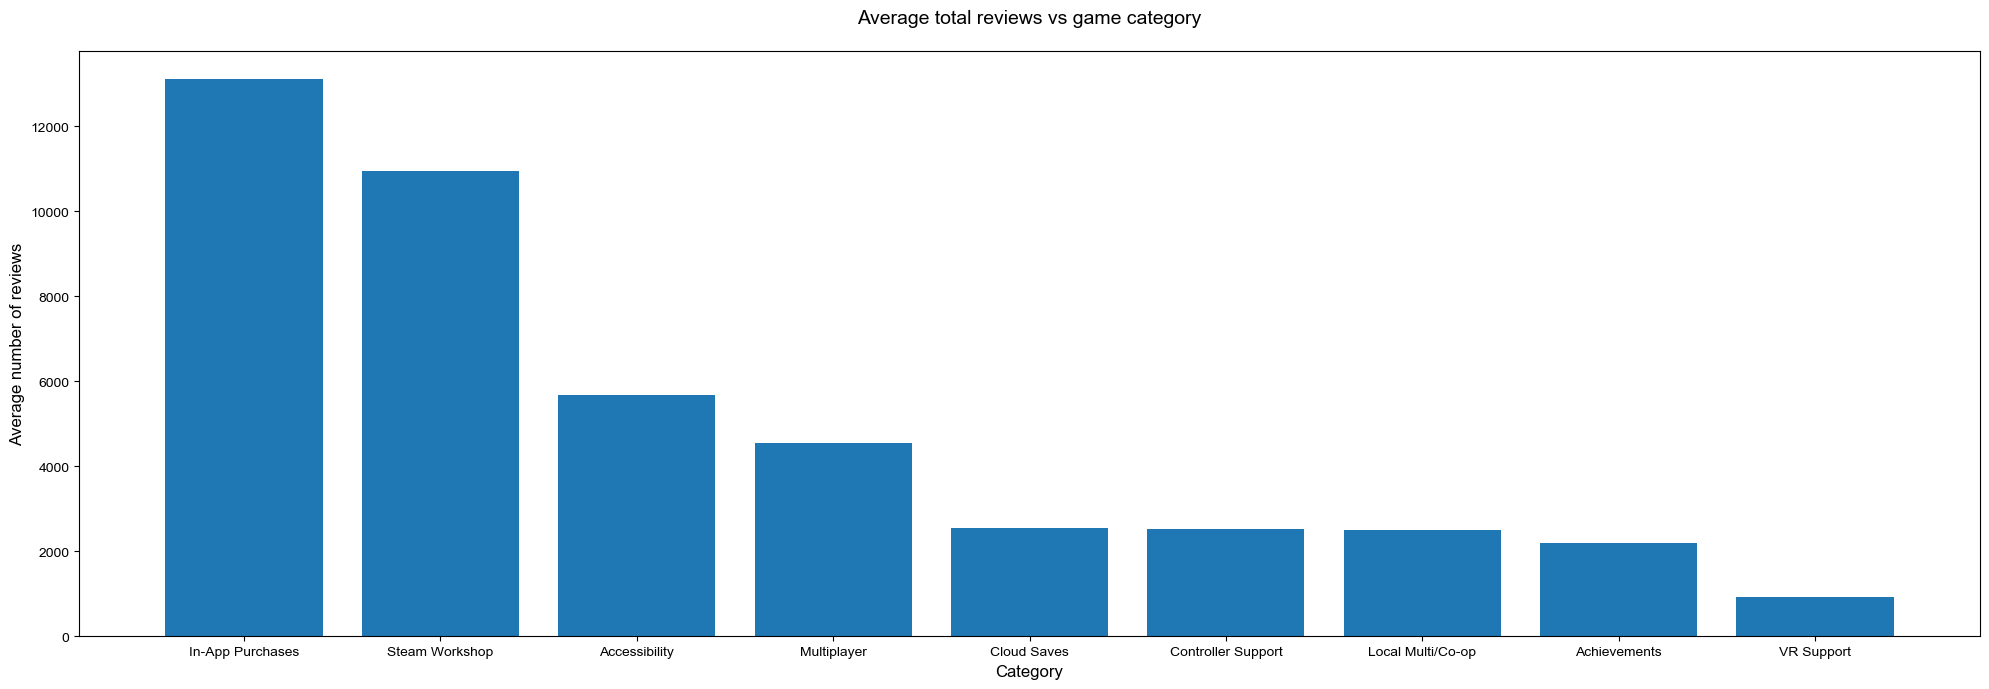

In [31]:
total_reviews = df['Positive'] + df['Negative']

category_cols = {
    'has_multiplayer': 'Multiplayer',
    'has_local_multi': 'Local Multi/Co-op',
    'has_workshop': 'Steam Workshop',
    'has_achievements': 'Achievements',
    'has_controller_support': 'Controller Support',
    'has_cloud_saves': 'Cloud Saves',
    'has_vr': 'VR Support',
    'has_accessibility_opts': 'Accessibility',
    'has_iap': 'In-App Purchases'
}

mean_reviews = {
    name: total_reviews[df[col] == 1].mean() 
    for col, name in category_cols.items()
}
mean_reviews = dict(sorted(mean_reviews.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(20, 7))
bars = plt.bar(mean_reviews.keys(), mean_reviews.values())

plt.title('Average total reviews vs game category', fontsize=14, pad=20)
plt.ylabel('Average number of reviews', fontsize=12)
plt.xlabel('Category', fontsize=12)

plt.tight_layout()
plt.show()

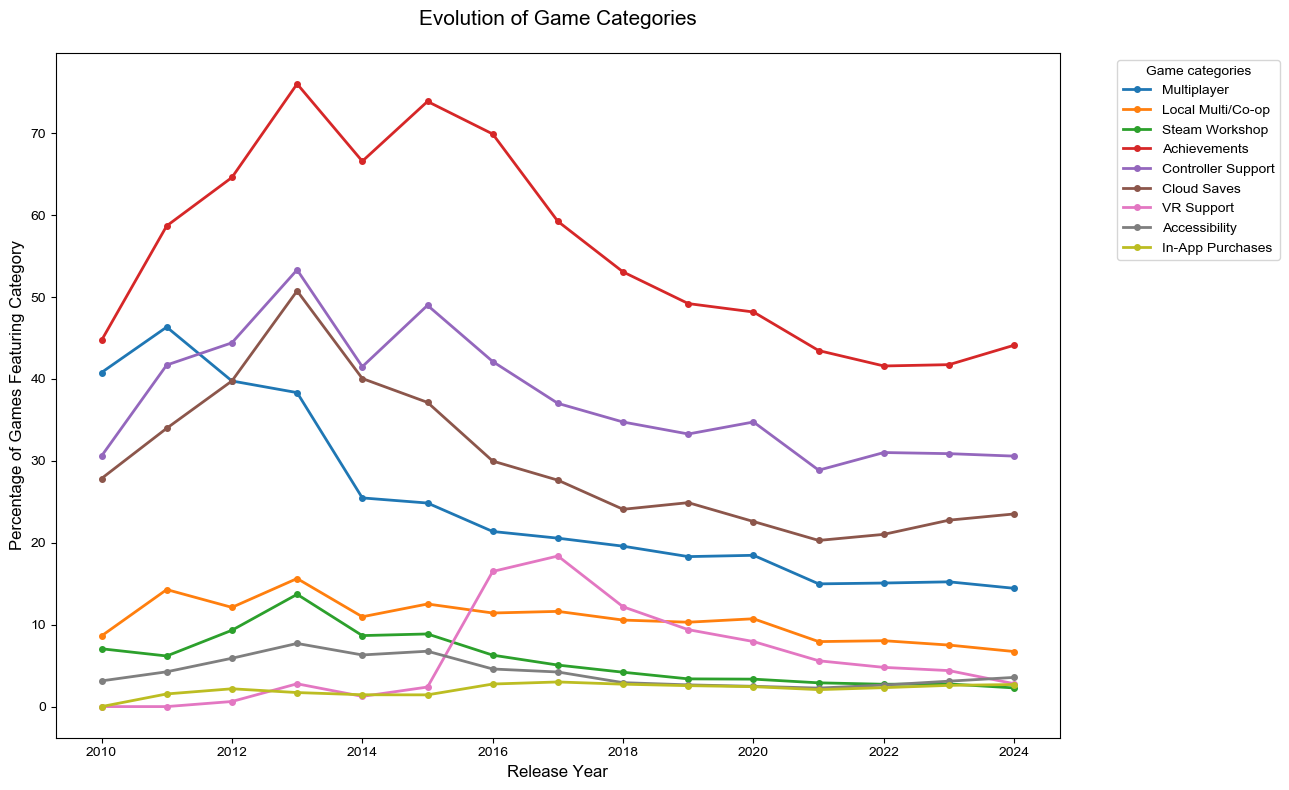

In [32]:
temp_years = pd.to_datetime(df['Release date'], errors='coerce').dt.year

mask_years = (temp_years >= 2010) & (temp_years <= 2024)
filtered_years = temp_years[mask_years]
yearly_total = filtered_years.value_counts().sort_index()

plt.figure(figsize=(13, 8))

for col, label in category_cols.items():
    yearly_top = df[mask_years].groupby(filtered_years)[col].sum()
    trend = (yearly_top / yearly_total) * 100
    
    plt.plot(trend.index, trend.values, label=label, marker='o', markersize=4, linewidth=2)

plt.title('Evolution of Game Categories', fontsize=15, pad=20)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Percentage of Games Featuring Category', fontsize=12)

plt.legend(title='Game categories', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

In [34]:
all_genres = [g for sublist in df['Genres'] for g in sublist]
#set(all_genres)

In [35]:
genre_mapping = {
    'genre_action': ['Action', 'Shooter', 'FPS', 'Fighting', 'Bullet Hell', 'Hack and Slash', 'Fast-Paced'],
    'genre_rpg': ['RPG', 'Action RPG', 'JRPG', 'Strategy RPG', 'Souls-like', 'Dungeon Crawler'],
    'genre_strategy': ['Strategy', 'RTS', 'Turn-Based Strategy', 'Grand Strategy', 'Tower Defense'],
    'genre_sim_mgmt': ['Simulation', 'Management', 'City Builder', 'Base-Building', 'Economy'],
    'genre_casual_puzzle': ['Casual', 'Puzzle', 'Hidden Object', 'Match 3', 'Logic', 'Board Game'],
    'genre_rogue': ['Rogue-like', 'Rogue-lite', 'Action Roguelike', 'Deckbuilding', 'Roguelike Deckbuilder'],
    'genre_adventure': ['Adventure', 'Open World', 'Metroidvania', 'Exploration', 'Story Rich'],
    'genre_visual_novel': ['Visual Novel', 'Anime', 'Dating Sim', 'Interactive Fiction'],
    'genre_horror': ['Horror', 'Psychological Horror', 'Survival Horror', 'Zombies'],
    'genre_adult': ['Hentai', 'Sexual Content', 'Nudity', 'NSFW'],
    'genre_multiplayer': ['Multiplayer', 'Massively Multiplayer', 'Co-op', 'Online Co-Op', 'PvP', 'Battle Royale']
}

def map_genres_to_meta(genre_list):
    
    found_genres = []
    for genre, keywords in genre_mapping.items():
        if any(k in genre_list for k in keywords):
            found_genres.append(genre)

    return found_genres

meta_genre_assignments = df['Genres'].apply(map_genres_to_meta)

for g_key in genre_mapping.keys():
    df[g_key] = meta_genre_assignments.apply(lambda x: 1 if g_key in x else 0)

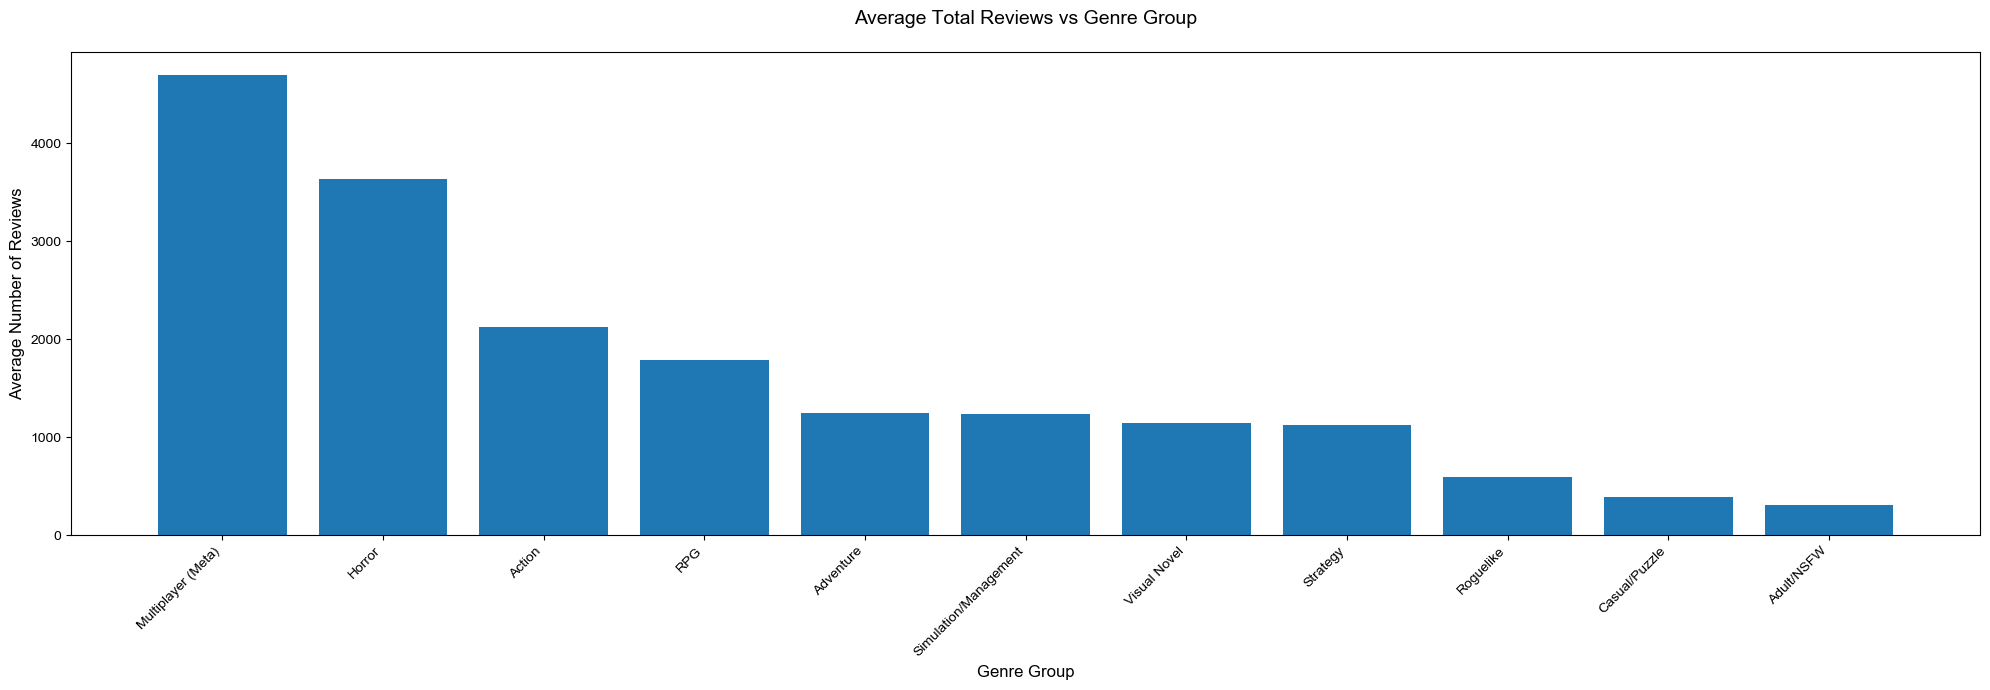

In [37]:
genre_labels = {
    'genre_action': 'Action',
    'genre_rpg': 'RPG',
    'genre_strategy': 'Strategy',
    'genre_sim_mgmt': 'Simulation/Management',
    'genre_casual_puzzle': 'Casual/Puzzle',
    'genre_rogue': 'Roguelike',
    'genre_adventure': 'Adventure',
    'genre_visual_novel': 'Visual Novel',
    'genre_horror': 'Horror',
    'genre_adult': 'Adult/NSFW',
    'genre_multiplayer': 'Multiplayer (Meta)'
}

mean_genre_reviews = {
    label: total_reviews[df[col] == 1].mean() 
    for col, label in genre_labels.items()
}

mean_genre_reviews = dict(sorted(mean_genre_reviews.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(20, 7))
plt.bar(mean_genre_reviews.keys(), mean_genre_reviews.values())

plt.title('Average Total Reviews vs Genre Group', fontsize=14, pad=20)
plt.ylabel('Average Number of Reviews', fontsize=12)
plt.xlabel('Genre Group', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

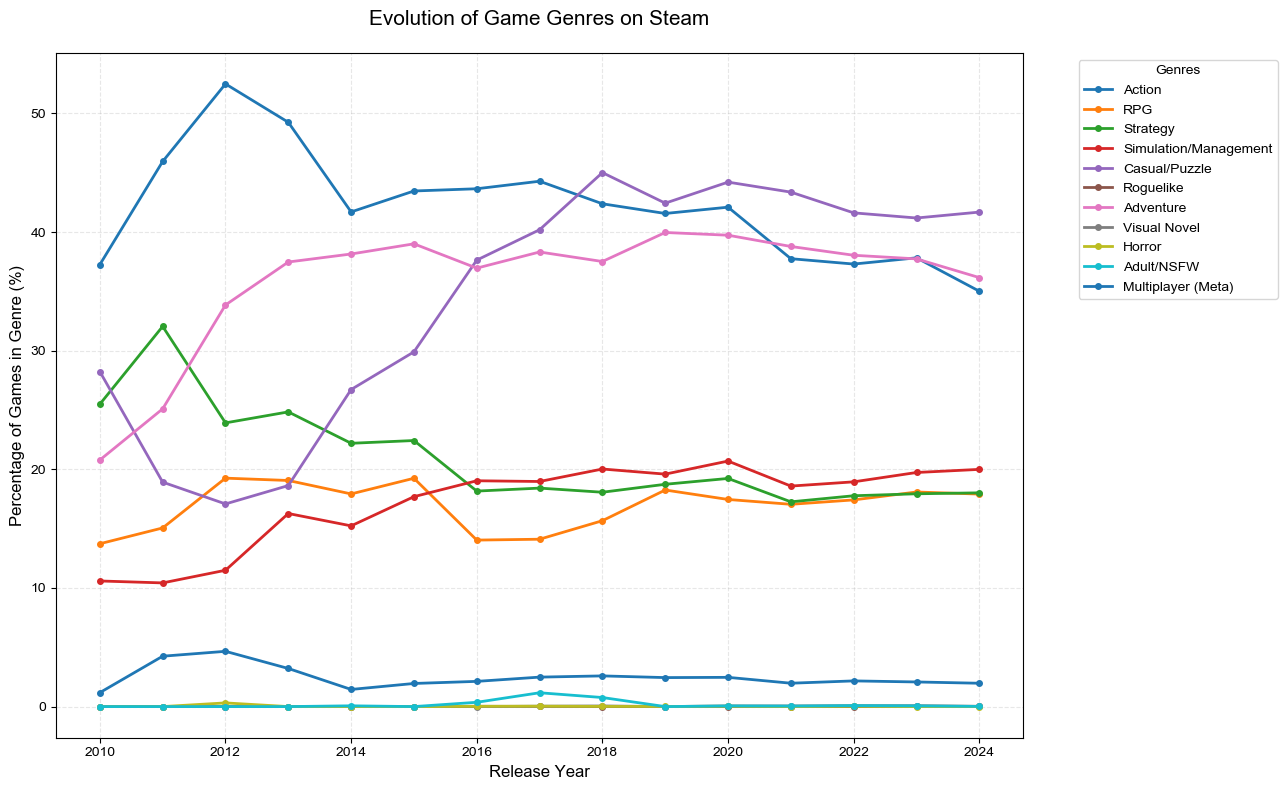

In [39]:

plt.figure(figsize=(13, 8))

for col, label in genre_labels.items():
    yearly_genre_count = df[mask_years].groupby(filtered_years)[col].sum()
    genre_trend = (yearly_genre_count / yearly_total) * 100
    
    plt.plot(genre_trend.index, genre_trend.values, label=label, marker='o', markersize=4, linewidth=2)

plt.title('Evolution of Game Genres on Steam', fontsize=15, pad=20)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Percentage of Games in Genre (%)', fontsize=12)

plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

"Multiplayer" is currently both in categories and in genres- I will remove the one from genres for two main reasons:
- redundancy: both columns represent the same feature, which can confuse the model,
- data reliability: categories are technical specifications provided by the developer. If a game is listed here as Multiplayer, it means the functional infrastructure (servers, matchmaking) exists. 

Genres are often community-driven or used for marketing. They are "messier" and can be subjective - for example, a game might be tagged as "multiplayer" simply because it has a leaderboard or something like that.
  

In [854]:
df.drop(columns=['Categories', 'Tags', 'Genres', 'genre_multiplayer'], inplace=True)

Now the column 'About the game'.

In [855]:
# about the game
print(df[df['About the game'].isna()].shape)

(8449, 48)


In [856]:
df[
    ~(df['About the game'].isna()) &
    df['Name'].str.contains('alpha|beta|playtest', case=False, na=False)
].shape

(202, 48)

In [857]:
df[
    (df['About the game'].isna()) &
    ~df['Name'].str.contains('alpha|beta|playtest', case=False, na=False)
].shape

(272, 48)

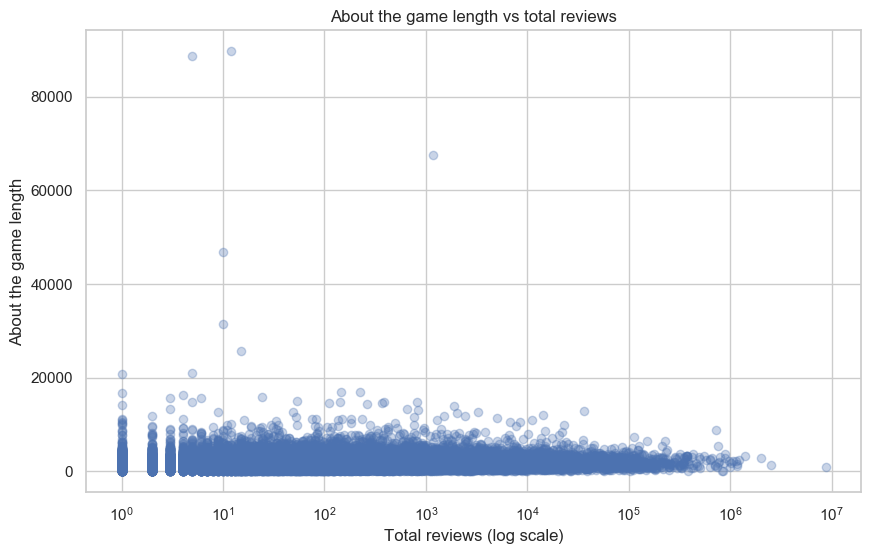

In [858]:
df_plt_about_reviews = df.copy()


df_plt_about_reviews['about_length'] = df_plt_about_reviews['About the game'].str.len().fillna(0)
df_plt_about_reviews['total_reviews'] = df_plt_about_reviews['Positive'] + df_plt_about_reviews['Negative']

df_plt_about_reviews = df_plt_about_reviews.dropna(subset=['about_length', 'total_reviews'])

fig_about_reviews, ax_about_reviews = plt.subplots(figsize=(10, 6))
ax_about_reviews.scatter(df_plt_about_reviews['total_reviews'], df_plt_about_reviews['about_length'], alpha=0.3)
ax_about_reviews.set_ylabel('About the game length')
ax_about_reviews.set_xlabel('Total reviews (log scale)')
ax_about_reviews.set_title('About the game length vs total reviews')
ax_about_reviews.set_xscale('log')

In [859]:
def parse_owners(x):
    if pd.isna(x):
        return None
    
    x = x.replace(',', '').replace(' ', '')
    
    low, high = x.split('-')
    return (int(low) + int(high)) / 2

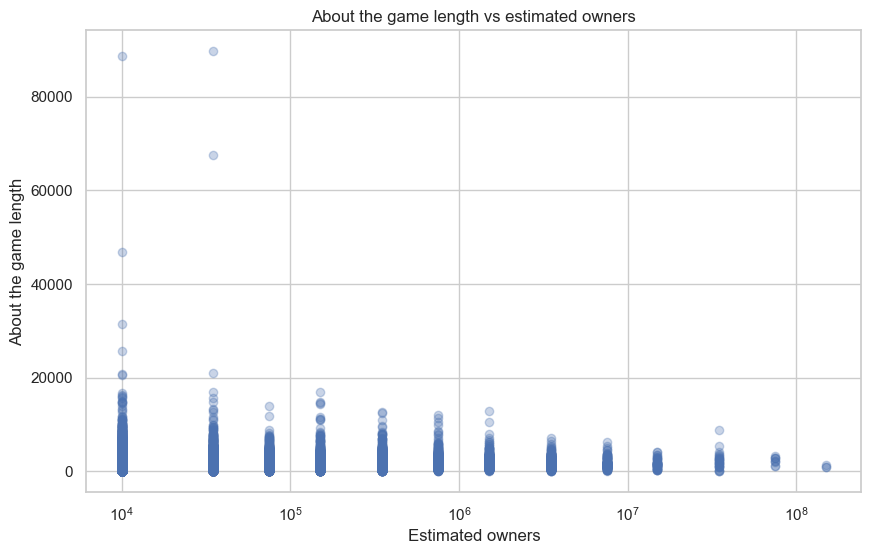

In [860]:
df_plt_about_owners = df.copy()


df_plt_about_owners['about_length'] = df_plt_about_owners['About the game'].str.len().fillna(0)
df_plt_about_owners['estimated_owners'] = df_plt_about_owners['Estimated owners'].apply(parse_owners)

df_plt_about_owners = df_plt_about_owners.dropna(subset=['about_length', 'estimated_owners'])

fig_about_owners, ax_about_owners = plt.subplots(figsize=(10, 6))
ax_about_owners.scatter(df_plt_about_owners['estimated_owners'], df_plt_about_owners['about_length'], alpha=0.3)
ax_about_owners.set_ylabel('About the game length')
ax_about_owners.set_xlabel('Estimated owners')
ax_about_owners.set_title('About the game length vs estimated owners')
ax_about_owners.set_xscale('log')

Presence of "About the game" cannot be connected with a game not being a playtest etc. There is a slight interesting corresponding between the length of description and number of reviews or estimated owners- I will take a closer look on this later in this report. On the two plots above we can see some outliers so I will also remove them.

In [861]:
df['about_length'] = df['About the game'].str.len().fillna(0)
df = df[df['about_length'] <= 4000]
df.drop(columns='About the game', inplace=True)

I will perform the same analysis on "Name" column.

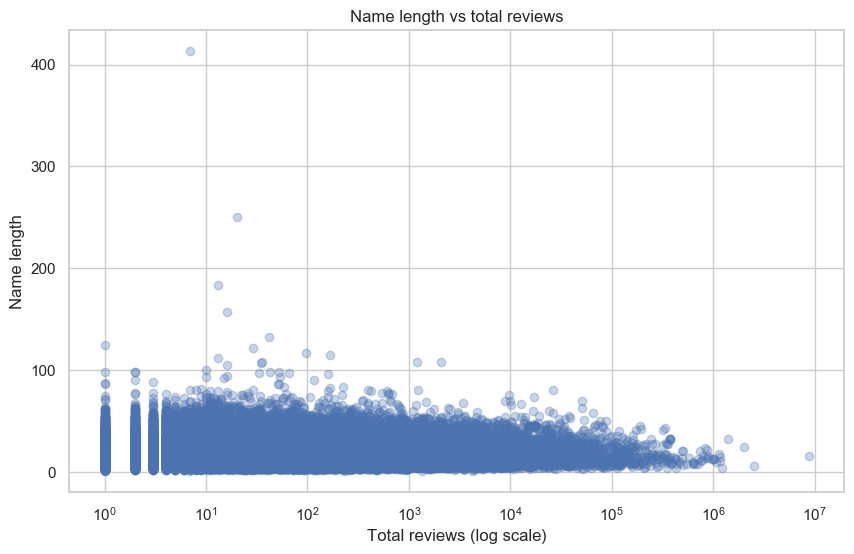

In [862]:
df_plt_name_reviews = df.copy()
df_plt_name_reviews['name_length'] = df_plt_name_reviews['Name'].str.len().fillna(0)
df_plt_name_reviews['total_reviews'] = df_plt_name_reviews['Positive'] + df_plt_name_reviews['Negative']
df_plt_name_reviews = df_plt_name_reviews.dropna(subset=['name_length', 'total_reviews'])

fig_name_reviews, ax_name_reviews = plt.subplots(figsize=(10, 6))
ax_name_reviews.scatter(df_plt_name_reviews['total_reviews'], df_plt_name_reviews['name_length'], alpha=0.3)
ax_name_reviews.set_ylabel('Name length')
ax_name_reviews.set_xlabel('Total reviews (log scale)')
ax_name_reviews.set_title('Name length vs total reviews')
ax_name_reviews.set_xscale('log')

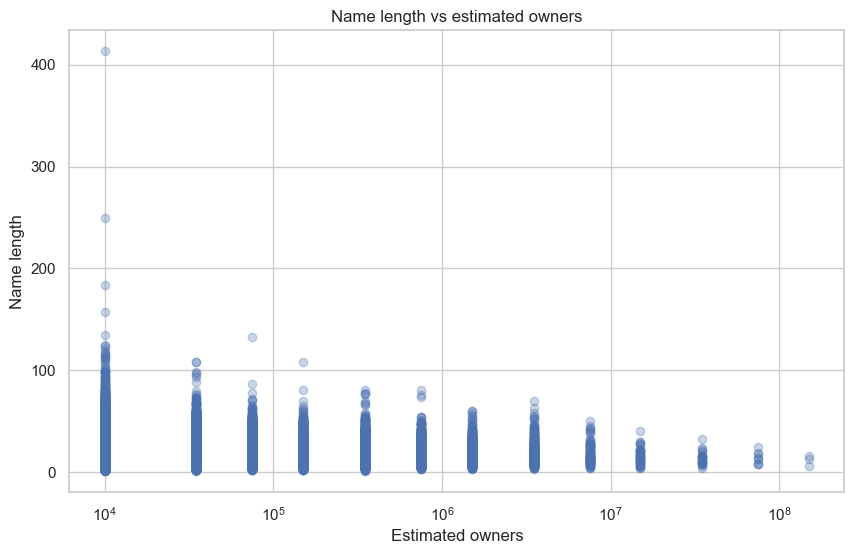

In [863]:
df_plt_name_owners = df.copy()
df_plt_name_owners['name_length'] = df_plt_name_owners['Name'].str.len().fillna(0)
df_plt_name_owners['estimated_owners'] = df_plt_name_owners['Estimated owners'].apply(parse_owners)
df_plt_name_owners = df_plt_name_owners.dropna(subset=['name_length', 'estimated_owners'])

fig_name_owners, ax_name_owners = plt.subplots(figsize=(10, 6))
ax_name_owners.scatter(df_plt_name_owners['estimated_owners'], df_plt_name_owners['name_length'], alpha=0.3)
ax_name_owners.set_ylabel('Name length')
ax_name_owners.set_xlabel('Estimated owners')
ax_name_owners.set_title('Name length vs estimated owners')
ax_name_owners.set_xscale('log')

We can see a very similar pattern for the "Name" column as for the 'About the game' one. There are also a few visible outliers, so I will remove games with a name length exceeding 150 characters.

In [864]:
df['name_length'] = df['Name'].str.len().fillna(0)
df = df[df['name_length'] <= 150]

Now let's look at the languages.

In [865]:
def get_strategic_languages(x):
    if pd.isna(x):
        return []
    
    x = str(x).replace('\\r', ' ').replace('\\n', ' ')
    prev_x = ""
    while x != prev_x:
        prev_x = x
        x = html.unescape(x)
    
    x = re.sub(r'<.*?>|\[/?b\]|\(.*?\)', ' ', x)
    parts = re.split(r'[,;&\s]{2,}|[,;&]', x)
    
    mapping = {
        'english': 'English',
        'french': 'French',
        'german': 'German',
        'italian': 'Italian',
        'spanish': 'Spanish',
        'portuguese': 'Portuguese',
        'russian': 'Russian',
        'polish': 'Polish',
        'turkish': 'Turkish',
        'japanese': 'Japanese',
        'korean': 'Korean',
        'simplified chinese': 'Chinese',
        'traditional chinese': 'Chinese',
        'chinese': 'Chinese'
    }
    
    cleaned = []
    for p in parts:
        p = p.strip(" '\"[]:.").lower()
        p = re.split(r'\s-\s|\s\(', p)[0]
        
        if p in mapping:
            cleaned.append(mapping[p])
        elif len(p) > 2:
            cleaned.append('Other')
            
    return list(dict.fromkeys(cleaned))


In [866]:
df['lang_list'] = df['Supported languages'].apply(get_strategic_languages)
df['audio_list'] = df['Full audio languages'].apply(get_strategic_languages)

top_langs = ['English', 'French', 'German', 'Italian', 'Spanish', 'Chinese', 'Japanese', 'Korean', 'Russian', 'Portuguese', 'Polish']

for lang in top_langs:
    df[f'lang_{lang}'] = df['lang_list'].apply(lambda x: 1 if lang in x else 0)

for lang in top_langs:
    df[f'has_audio_{lang}'] = df['audio_list'].apply(lambda x: 1 if lang in x else 0)

df['lang_count'] = df['lang_list'].apply(len)
df['audio_count'] = df['audio_list'].apply(len)

In [623]:
df.head()

,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_list,audio_list,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,total_lang_count,audio_count
2539430,Black Dragon Mage Playtest,2023-08-01,0 - 0,0,0.00,0,0,[],[],True,False,False,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,[],[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0 - 20000,0,5.24,65,0,['English'],[],True,False,False,0,0,252,3,0,231,8,8,1,1,1,0,1,10,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1626.0,37,[English],[],1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1034400,Mystery Solitaire The Black Raven,2019-05-06,0 - 20000,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],True,True,False,0,0,21,3,0,0,0,0,1,1,1,0,1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1178.0,33,"[English, French, German, Russian]",[],1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0
3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,0 - 20000,0,8.99,0,1,['Korean'],['Korean'],True,False,False,0,0,0,0,19,0,0,0,1,0,0,0,1,7,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1827.0,27,[Korean],[Korean],0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1
3631080,Maze Quest VR,2025-04-24,0 - 20000,0,4.99,0,0,['English'],['English'],True,False,False,0,0,0,0,0,0,0,0,1,1,1,0,1,6,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1483.0,13,[English],[English],1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1


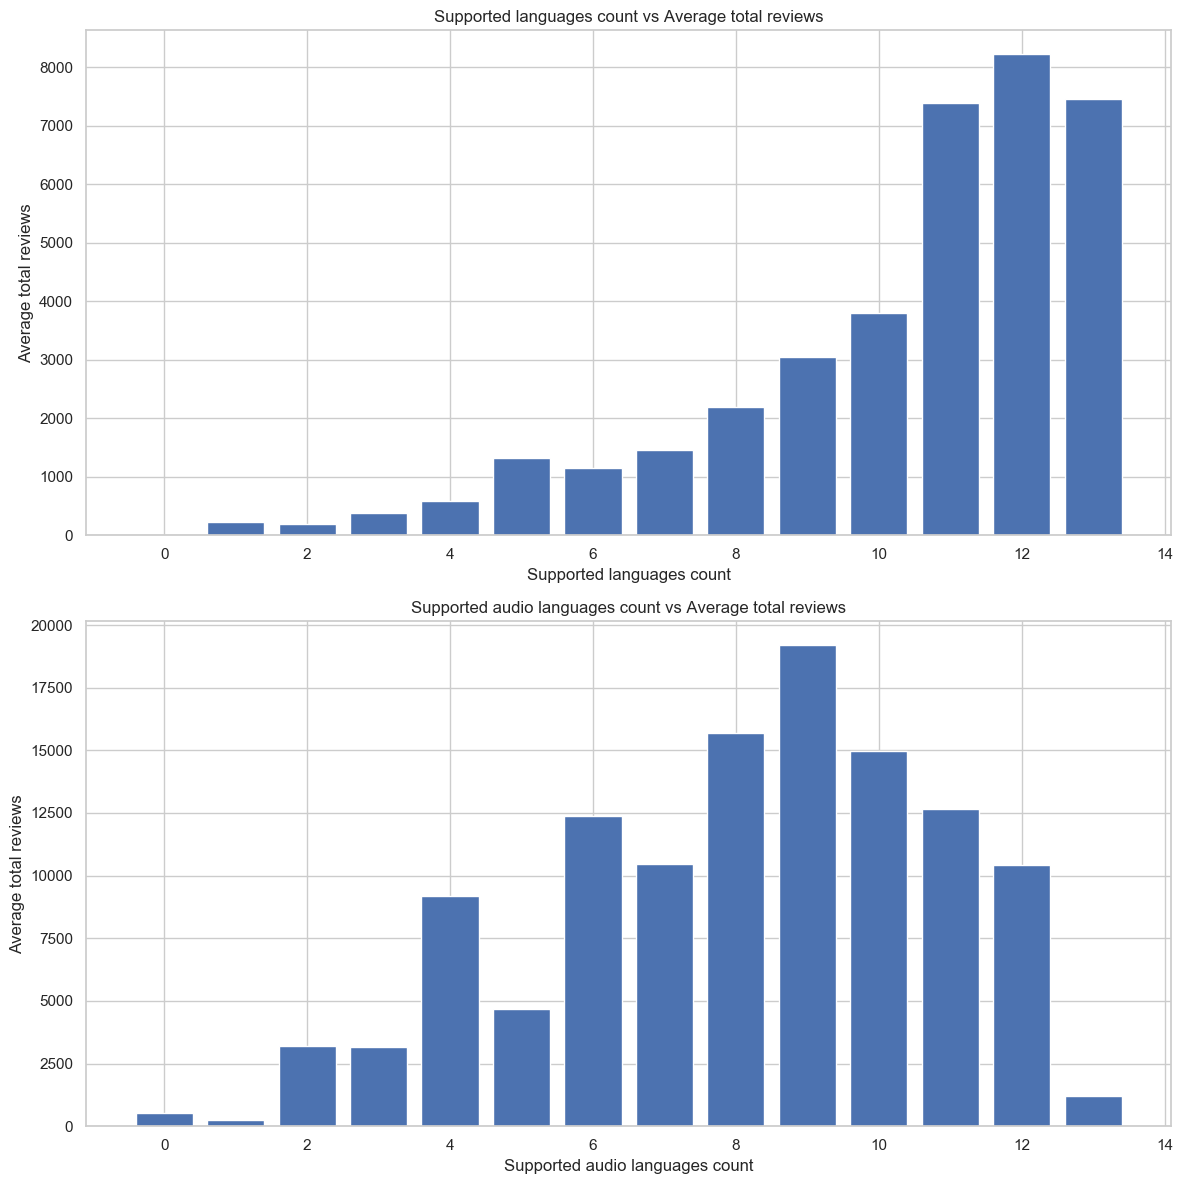

In [867]:
df['total_reviews'] = df['Positive'] + df['Negative']

stats_lang = df[df['lang_count'] <= 20].groupby('lang_count')['total_reviews'].mean()
stats_audio = df[df['audio_count'] <= 20].groupby('audio_count')['total_reviews'].mean()


plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
plt.bar(stats_lang.index, stats_lang.values)
plt.title('Supported languages count vs Average total reviews')
plt.ylabel('Average total reviews')
plt.xlabel('Supported languages count')

plt.subplot(2, 1, 2)
plt.bar(stats_audio.index, stats_audio.values)
plt.title('Supported audio languages count vs Average total reviews')
plt.xlabel('Supported audio languages count')
plt.ylabel('Average total reviews')

plt.tight_layout()
plt.show()

In [868]:
df.drop(['lang_list', 'audio_list', 'total_reviews', 'Supported languages', 'Full audio languages'], axis=1, inplace=True)

In [869]:
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing': df.isna().sum().values,
    'Percentage': (df.isna().sum() / len(df) * 100).round(2).values
}).sort_values('Percentage', ascending=False).reset_index(drop=True)

missing[missing['Missing'] > 0]

,Column,Missing,Percentage


There's no more missing data. The next step will be turning the remaining bool and object features into int/float.

In [870]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120596 entries, 2539430 to 4141790
Data columns (total 71 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Name                      120596 non-null  object        
 1   Release date              120596 non-null  datetime64[ns]
 2   Estimated owners          120596 non-null  object        
 3   Required age              120596 non-null  int64         
 4   Price                     120596 non-null  float64       
 5   Discount                  120596 non-null  int64         
 6   DLC count                 120596 non-null  int64         
 7   Windows                   120596 non-null  bool          
 8   Mac                       120596 non-null  bool          
 9   Linux                     120596 non-null  bool          
 10  Metacritic score          120596 non-null  int64         
 11  User score                120596 non-null  int64         
 12  

In [871]:
df["Mac"] = df["Mac"].astype(int)
df["Windows"] = df["Windows"].astype(int)
df["Linux"] = df["Linux"].astype(int)

There's also "Estimated owners" column that was left as an objetc. Let's look at it. The bucket '0-0' seems interesting.

In [872]:
df[df['Estimated owners'] == '0 - 0'].head(10)

,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,lang_count,audio_count
2539430,Black Dragon Mage Playtest,2023-08-01,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1946890,Codename: Warlock Playtest,2022-03-25,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2260230,Midnight Dash,2023-01-09,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,17,0,0,0,1,0,0,0,1,10,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,898.0,13,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
2713630,Black Market,2025-01-24,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,892.0,12,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2349750,CyberVault Playtest,2023-03-08,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2628280,A Night In Omar's Burger Playtest,2023-10-04,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2731180,Blaster Multiplayer,2024-01-02,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,7,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1576.0,19,1,1,1,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,9,2
3854040,BRUTALISMUS: Dystopia,2025-07-31,0 - 0,0,1.39,0,1,1,1,1,0,0,0,0,1,0,0,0,1,0,0,0,1,24,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,1793.0,21,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
2310500,Ortheo's Interdimensional Jam Session,2023-08-10,0 - 0,0,0.00,0,0,1,1,0,0,0,0,0,13,0,0,0,1,1,1,0,1,5,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2591.0,37,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
2641000,Spider-Guy: Trapped in the Cheese Place,2024-02-21,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,6,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,442.0,39,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,13,13


In [873]:
def format_owners(range_str):
    if pd.isna(range_str):
        return range_str
    
    upper = int(range_str.split('-')[1])
    lower = int(range_str.split('-')[0])

    result = ""

    if lower >= 1_000_000:
        result += f"{lower // 1_000_000}M - "
    elif lower >= 1_000:
        result += f"{lower // 1_000}K - "
    else:
        result += f'{str(lower)} - '
    
    if upper >= 1_000_000:
        result += f"{upper // 1_000_000}M"
    elif upper >= 1_000:
        result += f"{upper // 1_000}K"
    else:
        result += str(upper)

    return result   

In [874]:
owners_counts = df['Estimated owners'].value_counts().reset_index()
owners_counts.columns = ['Estimated owners', 'Number of games']

owners_counts['Estimated owners'] = owners_counts['Estimated owners'].apply(format_owners)
owners_counts

,Estimated owners,Number of games
0,0 - 20K,74242
1,0 - 0,21479
2,20K - 50K,11149
3,50K - 100K,5218
4,100K - 200K,3354
5,200K - 500K,2752
6,500K - 1M,1104
7,1M - 2M,700
8,2M - 5M,390
9,5M - 10M,120


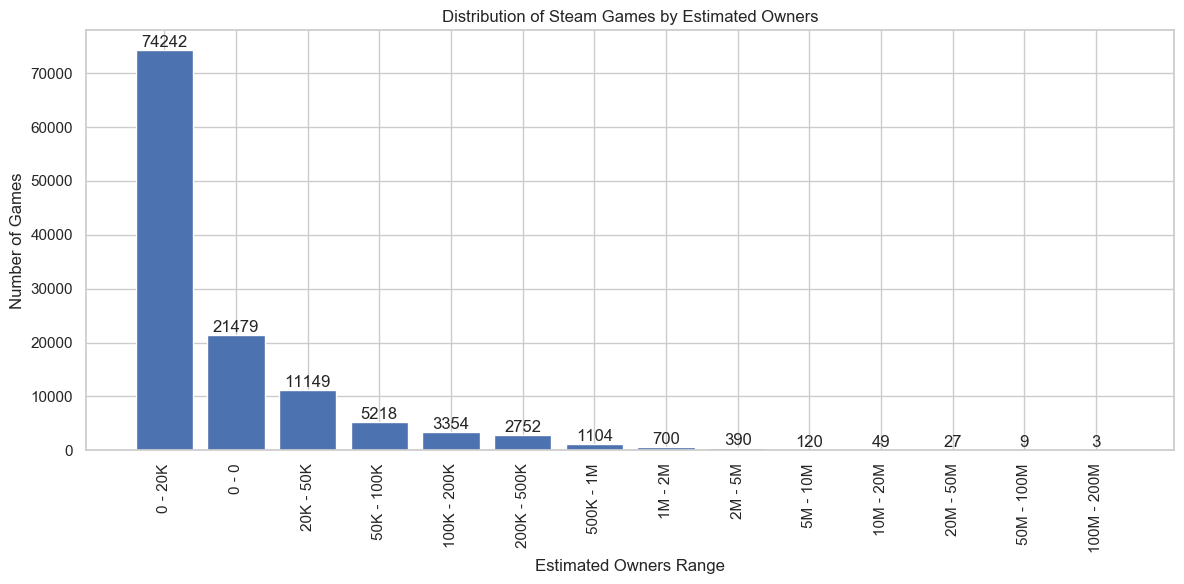

In [875]:
plt.figure(figsize=(12, 6))
plt.bar(
    owners_counts['Estimated owners'],
    owners_counts['Number of games'],
)

plt.xlabel("Estimated Owners Range")
plt.ylabel("Number of Games")
plt.title("Distribution of Steam Games by Estimated Owners")
plt.xticks(rotation=90)

for i, v in enumerate(owners_counts['Number of games']):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [876]:
cond_00_owners_playtest = (df['Estimated owners'] == '0 - 0') & \
                  (df['Name'].str.contains('playtest|alpha|beta|trial|demo|demo version', case=False, na=False) )

In [877]:
df [ cond_00_owners_playtest]

,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,lang_count,audio_count
2539430,Black Dragon Mage Playtest,2023-08-01,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1946890,Codename: Warlock Playtest,2022-03-25,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2349750,CyberVault Playtest,2023-03-08,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2628280,A Night In Omar's Burger Playtest,2023-10-04,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,33,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2689730,Dark and Deep Playtest,2024-03-20,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,22,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003950,Goblin Gladiators Playtest,2022-08-08,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1692440,Solys Playtest,2021-08-06,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3830800,Monster Truck Demolition Derby,2026-01-01,0 - 0,0,2.99,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,5,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,707.0,30,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3659430,Way of the Dragons Playtest,2025-04-12,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,12,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,27,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


There are over 21,000 games with an "0 - 0" estimated owners bucket. Around 8,000 of them are playtests or demo versions- not full released games- which also generate numerous outliers due to almost all their column values being missing. I will remove them from the dataset.

In [878]:
df = df[~cond_00_owners_playtest]

In [879]:
df[df['Estimated owners'] == '0 - 0'].head(50)

,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,lang_count,audio_count
2260230,Midnight Dash,2023-01-09,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,17,0,0,0,1,0,0,0,1,10,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,898.0,13,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
2713630,Black Market,2025-01-24,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,892.0,12,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2731180,Blaster Multiplayer,2024-01-02,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,7,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1576.0,19,1,1,1,1,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,9,2
3854040,BRUTALISMUS: Dystopia,2025-07-31,0 - 0,0,1.39,0,1,1,1,1,0,0,0,0,1,0,0,0,1,0,0,0,1,24,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,1793.0,21,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
2310500,Ortheo's Interdimensional Jam Session,2023-08-10,0 - 0,0,0.00,0,0,1,1,0,0,0,0,0,13,0,0,0,1,1,1,0,1,5,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2591.0,37,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
2641000,Spider-Guy: Trapped in the Cheese Place,2024-02-21,0 - 0,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,6,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,442.0,39,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,13,13
3797720,謎解き二十部屋,2025-07-09,0 - 0,0,4.79,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,5,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,503.0,7,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3491950,Food Truck Monopoly,2025-07-13,0 - 0,0,0.99,0,0,1,0,0,0,0,0,0,8,0,0,0,1,0,0,0,1,5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,491.0,19,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
4063660,Chronosurge: Echoes of the Void,2025-10-17,0 - 0,0,0.99,0,0,1,0,0,0,0,0,0,23,0,0,0,1,1,0,0,1,6,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,2019.0,31,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3976870,Rowen's Grand Adventure,2025-09-30,0 - 0,0,11.69,0,0,1,0,0,0,0,0,0,22,0,0,0,1,0,0,0,1,5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1203.0,23,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1


I googled some of the remaining games with 0-0 estimated owners. Some fo them are playtest, some of them are removed from steam and some of them are available to play. It would be too hard to analyze each game manually, so I will leave them in the dataset, but change their 'estimated owners' value to 0-2000 to place them in the lowest reasonable bucket

In [880]:
df['Estimated owners'] = df['Estimated owners'].replace('0 - 0', '0 - 2000')

Now I will turn buckets into an categorical ordinal feature.

In [881]:
def get_median_owners(x):
    low, high = x.replace(',', '').replace(' ', '').split('-')
    return (int(low) + int(high)) / 2

df['Estimated owners'] = df['Estimated owners'].apply(get_median_owners)
df.drop(columns='Name', inplace=True)

In [882]:
df['Estimated owners'].value_counts().sort_index()

Estimated owners
1000.0         13177
10000.0        74242
35000.0        11149
75000.0         5218
150000.0        3354
350000.0        2752
750000.0        1104
1500000.0        700
3500000.0        390
7500000.0        120
15000000.0        49
35000000.0        27
75000000.0         9
150000000.0        3
Name: count, dtype: int64

Over 74,000 games have less than 35000 owners, while only 2 games reach 150M. This huge gap means the raw values would overwhelm the model simply because the number difference. I will apply log1p here to squash the scale, so that the model will treat this feature more fairly alongside the rest.

In [883]:
df['Estimated owners'] = np.log1p(df['Estimated owners'])

I will also turn the release date column into month and year. Month will be one-hot encoded to avoid linear correlation between months.

In [884]:
df['release_year']  = pd.to_datetime(df['Release date'], errors='coerce').dt.year
df['release_month'] = pd.to_datetime(df['Release date'], errors='coerce').dt.month

month_dummies = pd.get_dummies(df['release_month'], prefix='month', drop_first=True).astype(int)
df = pd.concat([df, month_dummies], axis=1)
df.drop(columns=['release_month', 'Release date'], inplace=True)

### Interesting find

I have found a non-obvious pattern betweeen "About the game" and "Name" length and value of "Estimated owners" and "Positive" + "Negative" reviews. Let's take a look again at the plots that helpend me find this.

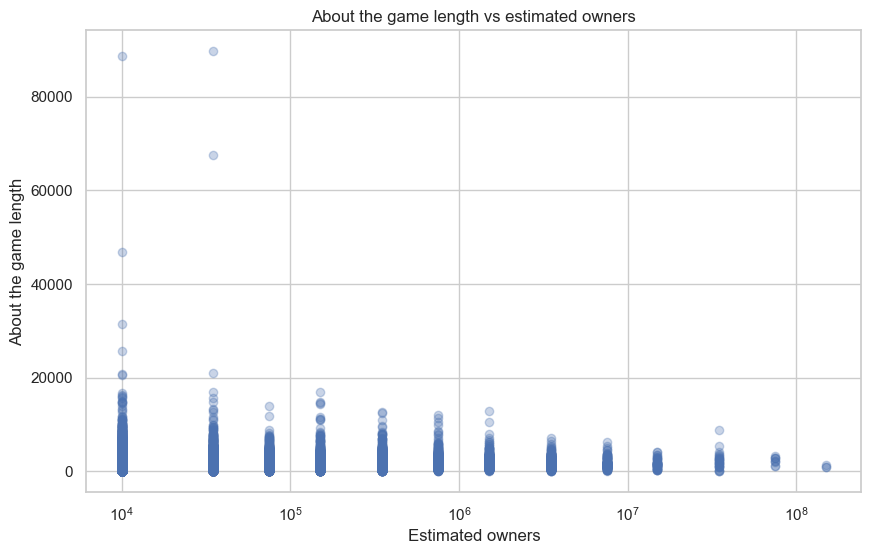

In [885]:
fig_about_owners

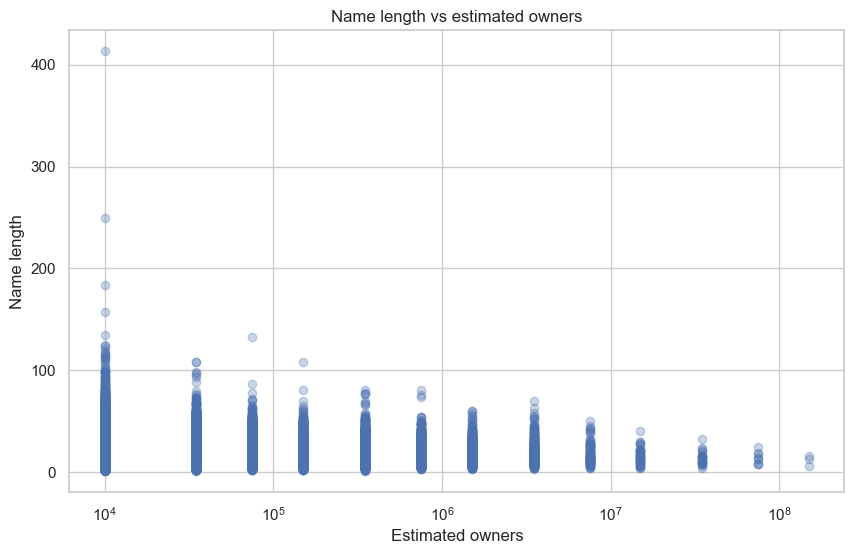

In [886]:
fig_name_owners

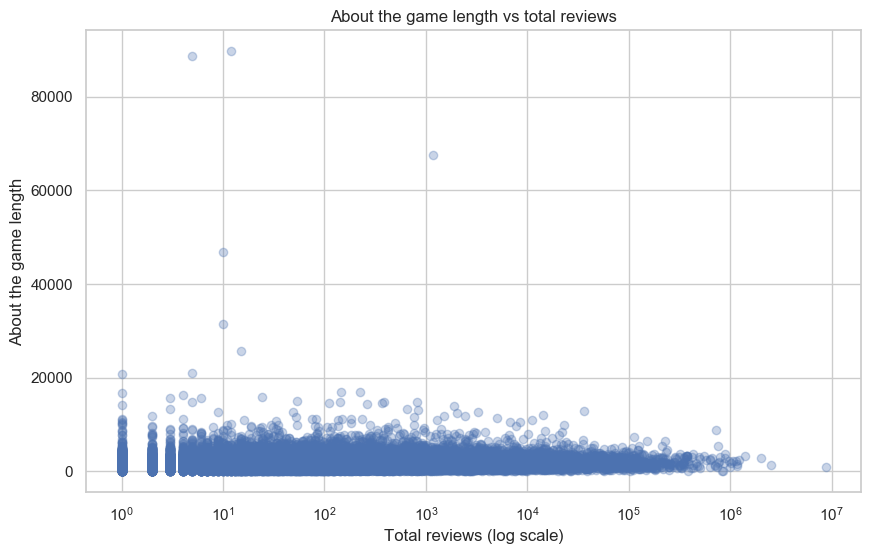

In [887]:
fig_about_reviews

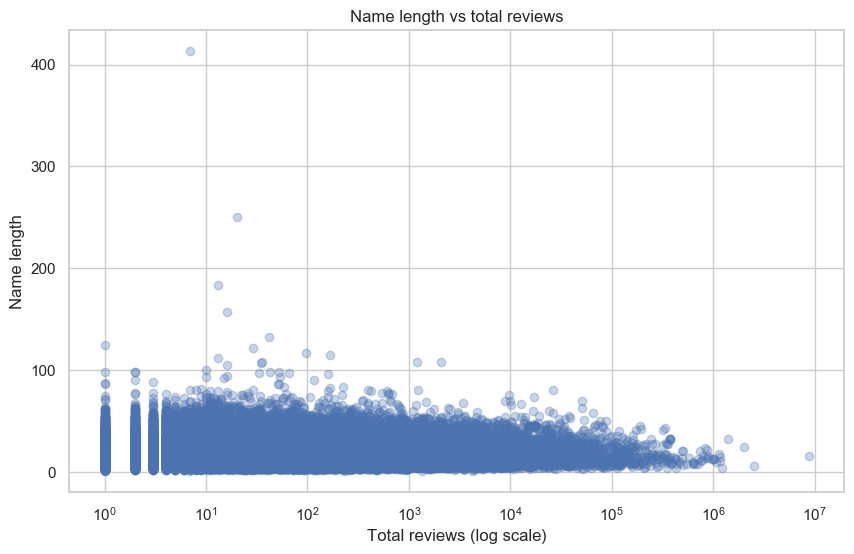

In [888]:
fig_name_reviews

To confirm this, I ran a statistical test called Spearman's rank correlation.

In [889]:
corr_about_reviews, pval_about_reviews = spearmanr(df_plt_about_reviews['about_length'], df_plt_about_reviews['total_reviews'])
corr_name_reviews, pval_name_reviews = spearmanr(df_plt_name_reviews['name_length'], df_plt_name_reviews['total_reviews'])

corr_about_owners, pval_about_owners = spearmanr(df_plt_about_owners['about_length'], df_plt_about_owners['estimated_owners'])
corr_name_owners, pval_name_owners = spearmanr(df_plt_name_owners['name_length'], df_plt_name_owners['estimated_owners'])

print(f"Test 'About the game' length vs total reviews: corr = {corr_about_reviews:.3f}, p-value = {pval_about_reviews:.3e}")
print(f"Test 'Name' length vs total reviews: corr = {corr_name_reviews:.3f}, p-value = {pval_name_reviews:.3e}")
print(f"Test 'About the game' length vs estimated owners: corr = {corr_about_owners:.3f}, p-value = {pval_about_owners:.3e}")
print(f"Test 'Name' length vs estimated owners: corr = {corr_name_owners:.3f}, p-value = {pval_name_owners:.3e}")

Test 'About the game' length vs total reviews: corr = 0.261, p-value = 0.000e+00
Test 'Name' length vs total reviews: corr = -0.037, p-value = 3.511e-38
Test 'About the game' length vs estimated owners: corr = 0.283, p-value = 0.000e+00
Test 'Name' length vs estimated owners: corr = -0.055, p-value = 3.985e-80


Looking at the results:
- Name length: the correlation is negative (-0.037 and -0.055). This says that shorter names mean more popular games.
- About the game length: the correlation is positive (0.261 and 0.283). This means the opposite: games with longer descriptions tend to have more reviews and owners.
  
The extremely low p-value (p < 0.05) proves that the relationship between text length and game success is not a coincidence. The length of the name and description really matters for a game's success on Steam, and it's not just a random accident in our data.

Based those results, publishers should:
- focus on shorter, catchy names, that are better for branding and searchability;
- detailed "About the game" section is a sign of a high-quality, professional product.

### Outliers

In this section, I will focus on columns that may contain outliers. These extreme values could mislead the model and negatively affect its performance, so they require careful handling.

In [894]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111522 entries, 496350 to 4141790
Data columns (total 81 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Estimated owners          111522 non-null  float64
 1   Required age              111522 non-null  int64  
 2   Price                     111522 non-null  float64
 3   Discount                  111522 non-null  int64  
 4   DLC count                 111522 non-null  int64  
 5   Windows                   111522 non-null  int64  
 6   Mac                       111522 non-null  int64  
 7   Linux                     111522 non-null  int64  
 8   Metacritic score          111522 non-null  int64  
 9   User score                111522 non-null  int64  
 10  Positive                  111522 non-null  int64  
 11  Negative                  111522 non-null  int64  
 12  Achievements              111522 non-null  int64  
 13  Recommendations           111522 non-null  

In [899]:
COLUMNS_TO_CHECK = [
    'release_year', 'Required age', 'Price', 'Discount', 'DLC count',
    'Metacritic score', 'User score', 'Positive', 'Negative',
    'Achievements', 'Recommendations', 'Average playtime forever',
    'Median playtime forever', 'Screenshots_count',
]

BOUNDED_COLUMNS = {
    'Discount': (0, 100),
}


def analyze_outliers(df: pd.DataFrame,
                     col: str,
                     iqr_multiplier: float = 1.5,
                     figsize: tuple = (10, 6)) -> dict:

    series = df[col].dropna()

    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    mn, mx = series.min(), series.max()
    skew   = series.skew()

    if col in BOUNDED_COLUMNS:
        lo, hi = BOUNDED_COLUMNS[col]
    else:
        lo = max(q1 - iqr_multiplier * iqr, 0) if mn >= 0 else q1 - iqr_multiplier * iqr
        hi = q3 + iqr_multiplier * iqr

    outlier_mask = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    n_out   = outlier_mask.sum()
    pct_out = n_out / len(df) * 100

    n_bins = min(80, max(20, int(len(series) ** 0.45)))

    can_log = mn >= 0
    series_log = np.log1p(series) if can_log else None
    lo_log     = np.log1p(lo)     if can_log else None
    hi_log     = np.log1p(hi)     if can_log else None

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(col, fontsize=12)
    ax_box, ax_box_log, ax_hist, ax_hist_log = axes.flat

    ax_box.boxplot(series, vert=False)
    ax_box.axvline(lo, color='red', linestyle='--', linewidth=1, label=f'IQR x {iqr_multiplier}')
    ax_box.axvline(hi, color='red', linestyle='--', linewidth=1)
    ax_box.set_yticks([])
    ax_box.set_xlabel('Value')
    ax_box.set_title('Boxplot')
    ax_box.legend(fontsize=8)

    if can_log:
        ax_box_log.boxplot(series_log, vert=False)
        ax_box_log.axvline(lo_log, color='red', linestyle='--', linewidth=1, label=f'IQR x {iqr_multiplier}')
        ax_box_log.axvline(hi_log, color='red', linestyle='--', linewidth=1)
        ax_box_log.set_yticks([])
        ax_box_log.set_xlabel('log(1+x)')
        ax_box_log.set_title('Boxplot [log]')
        ax_box_log.legend(fontsize=8)
    else:
        ax_box_log.axis('off')
        ax_box_log.text(0.5, 0.5, 'log not available\n(negative values)',
                        ha='center', va='center', transform=ax_box_log.transAxes)

    ax_hist.hist(series, bins=n_bins, color='steelblue', alpha=0.7)
    ax_hist.axvline(lo, color='red', linestyle='--', linewidth=1, label='bounds')
    ax_hist.axvline(hi, color='red', linestyle='--', linewidth=1)
    ax_hist.set_xlabel('Value')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title('Histogram')
    ax_hist.legend(fontsize=8)

    if can_log:
        ax_hist_log.hist(series_log, bins=n_bins, color='steelblue', alpha=0.7)
        ax_hist_log.axvline(lo_log, color='red', linestyle='--', linewidth=1, label='bounds')
        ax_hist_log.axvline(hi_log, color='red', linestyle='--', linewidth=1)
        ax_hist_log.set_xlabel('log(1+x)')
        ax_hist_log.set_ylabel('Count')
        ax_hist_log.set_title('Histogram [log]')
        ax_hist_log.legend(fontsize=8)
    else:
        ax_hist_log.axis('off')

    plt.tight_layout()
    plt.show()

    print(f'[{col}]  outliers: {n_out} ({pct_out:.2f}%)  |  bounds: [{lo:.2f}, {hi:.2f}]  |  min/max: {mn:.2f}/{mx:.2f}  |  skew: {skew:.2f}')

    return {
        'col': col, 'n_outliers': n_out, 'pct_outliers': pct_out,
        'lower_bound': lo, 'upper_bound': hi, 'outlier_mask': outlier_mask,
        'stats': {'q1': q1, 'q3': q3, 'iqr': iqr, 'skew': skew, 'min': mn, 'max': mx},
    }


def analyze_all(df: pd.DataFrame,
                columns: list[str] | None = None,
                iqr_multiplier: float = 1.5) -> pd.DataFrame:
    if columns is None:
        columns = [c for c in COLUMNS_TO_CHECK if c in df.columns]

    missing = [c for c in COLUMNS_TO_CHECK if c not in df.columns]
    if missing:
        print(f'Columns not found: {missing}\n')

    rows = []
    for col in columns:
        r = analyze_outliers(df, col, iqr_multiplier=iqr_multiplier)
        if r:
            rows.append({
                'Column':      r['col'],
                'N outliers':  r['n_outliers'],
                '% outliers':  round(r['pct_outliers'], 2),
                'Lower bound': round(r['lower_bound'], 2),
                'Upper bound': round(r['upper_bound'], 2),
                'Skewness':    round(r['stats']['skew'], 2),
                'Min':         round(r['stats']['min'], 2),
                'Max':         round(r['stats']['max'], 2),
            })

    summary = pd.DataFrame(rows).set_index('Column')
    return summary



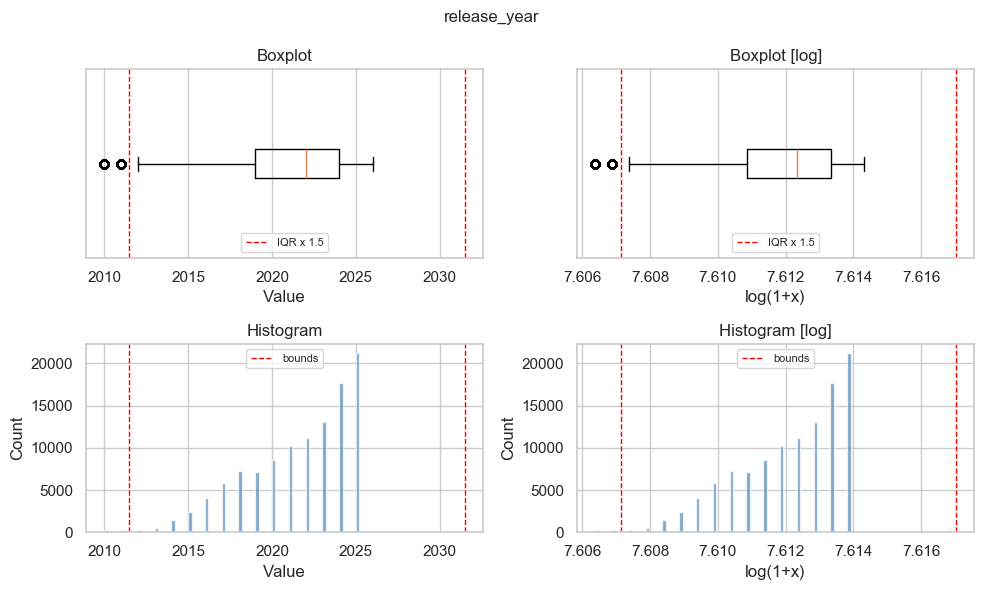

[release_year]  outliers: 507 (0.45%)  |  bounds: [2011.50, 2031.50]  |  min/max: 2010.00/2026.00  |  skew: -0.80


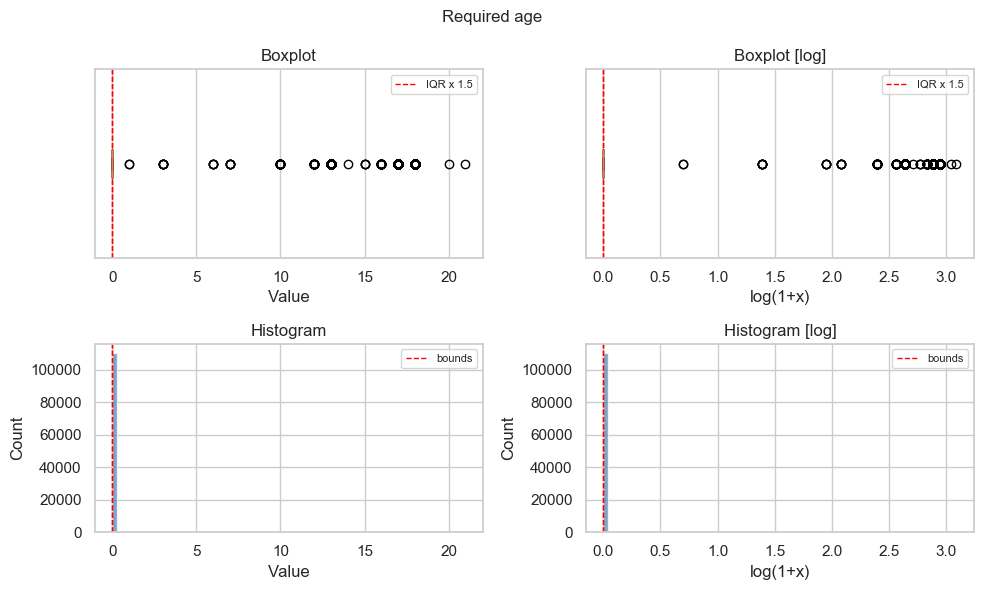

[Required age]  outliers: 1141 (1.02%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/21.00  |  skew: 9.97


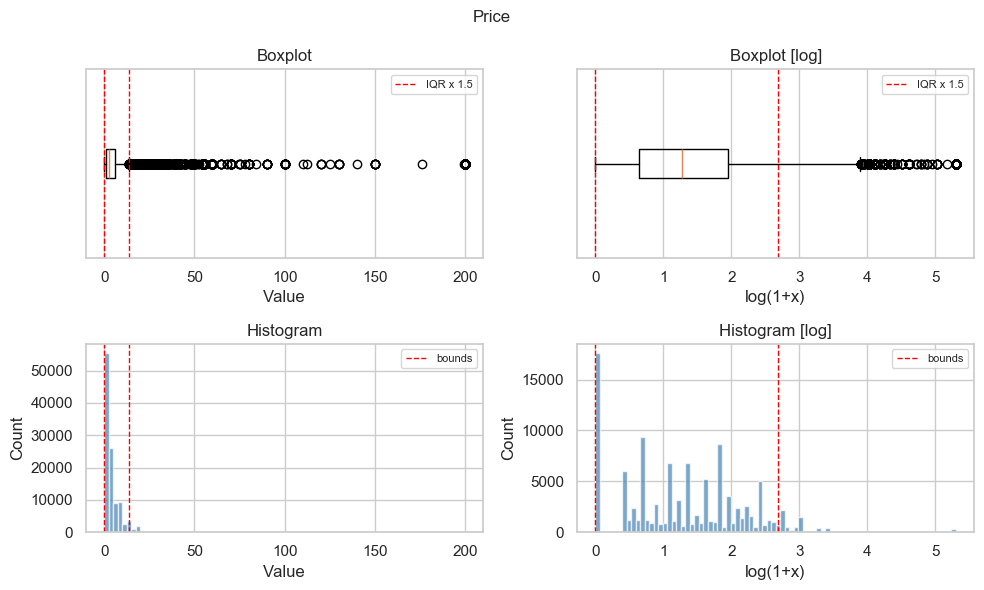

[Price]  outliers: 7579 (6.80%)  |  bounds: [0.00, 13.64]  |  min/max: 0.00/199.99  |  skew: 12.48


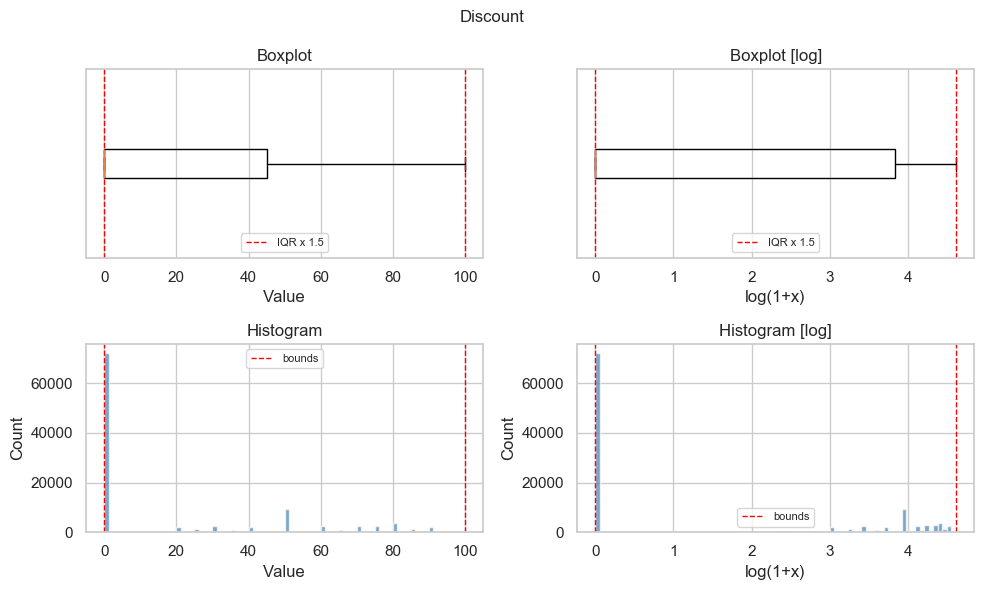

[Discount]  outliers: 0 (0.00%)  |  bounds: [0.00, 100.00]  |  min/max: 0.00/100.00  |  skew: 1.13


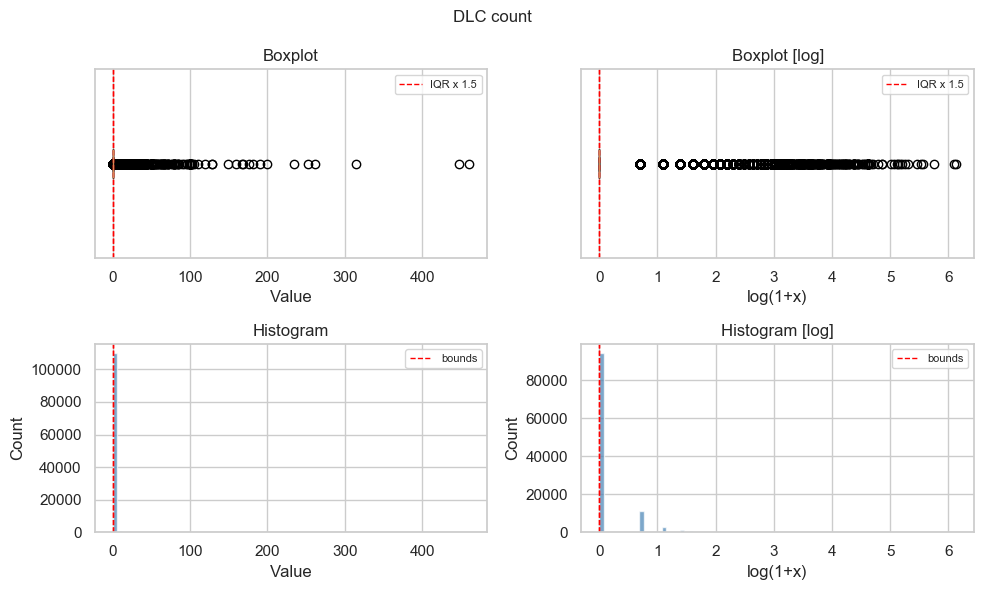

[DLC count]  outliers: 17127 (15.36%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/461.00  |  skew: 48.27


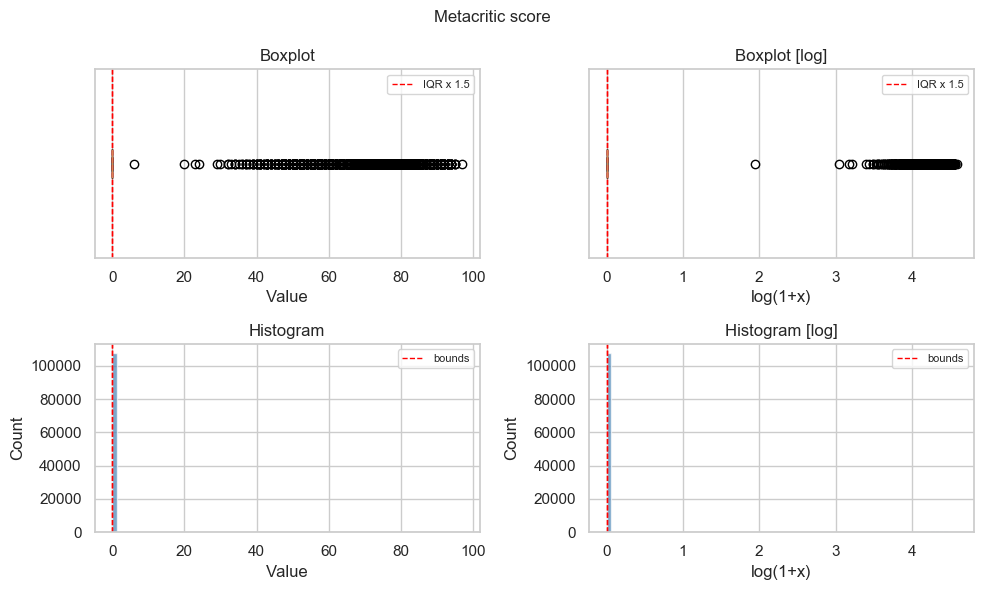

[Metacritic score]  outliers: 3769 (3.38%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/97.00  |  skew: 5.30


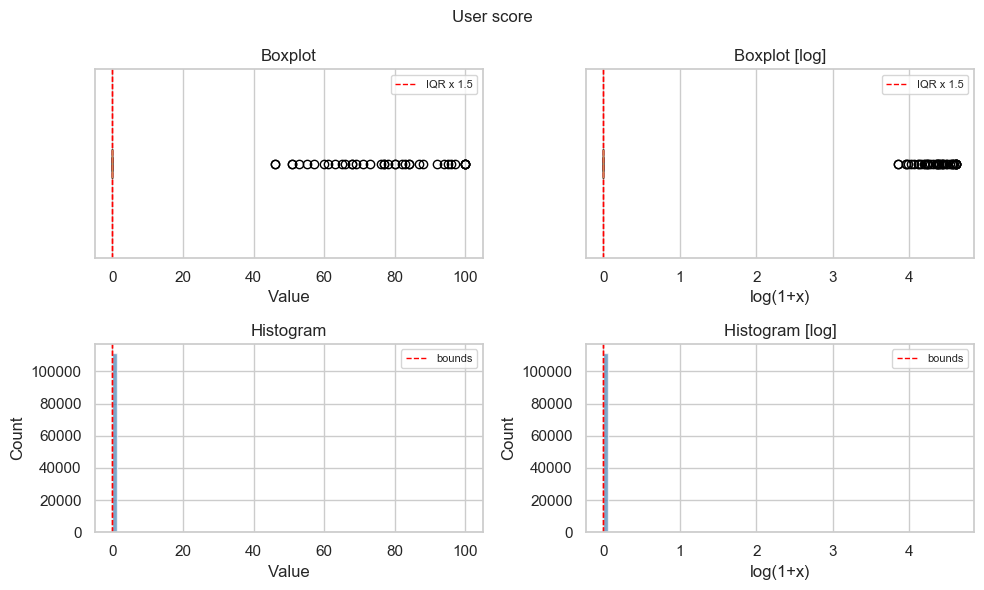

[User score]  outliers: 39 (0.03%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/100.00  |  skew: 56.85


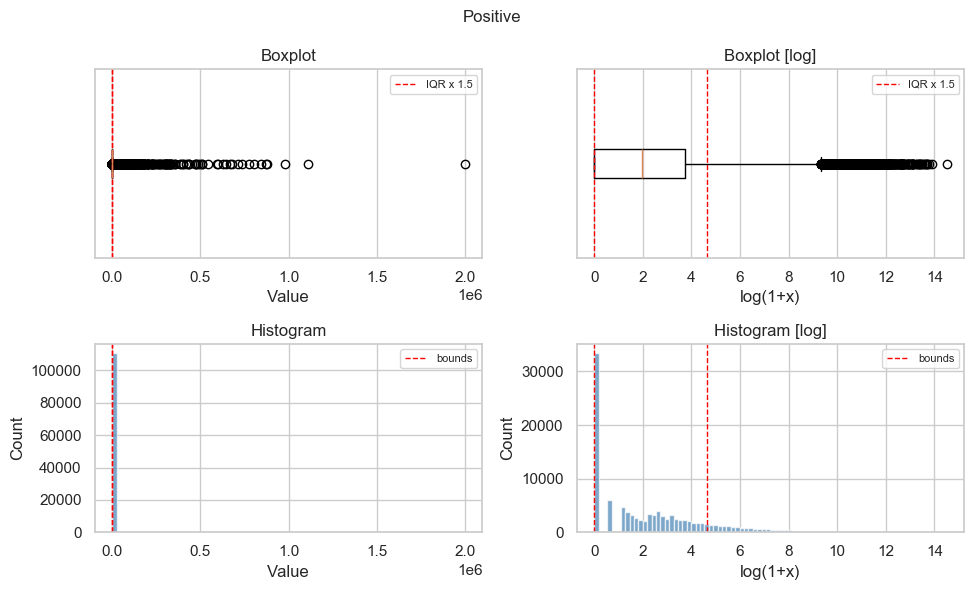

[Positive]  outliers: 18679 (16.75%)  |  bounds: [0.00, 102.50]  |  min/max: 0.00/2000000.00  |  skew: 54.60


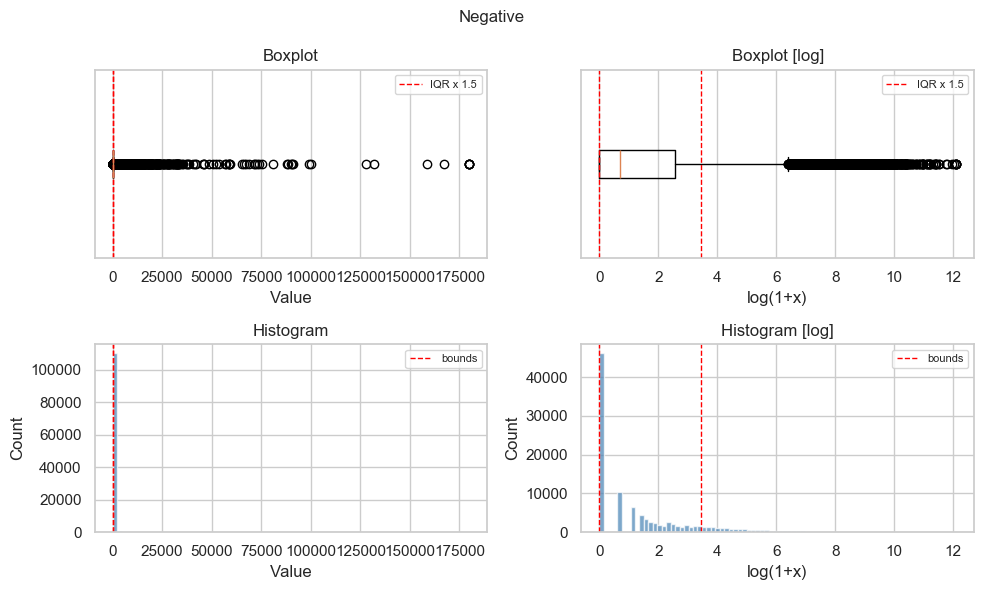

[Negative]  outliers: 17785 (15.95%)  |  bounds: [0.00, 30.00]  |  min/max: 0.00/180000.00  |  skew: 51.96


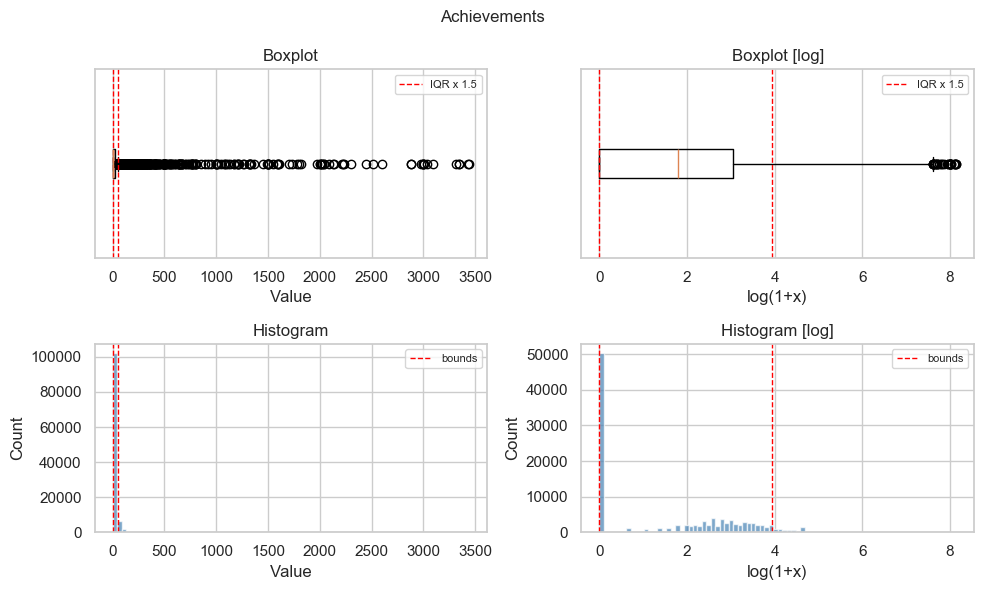

[Achievements]  outliers: 6738 (6.04%)  |  bounds: [0.00, 50.00]  |  min/max: 0.00/3445.00  |  skew: 32.95


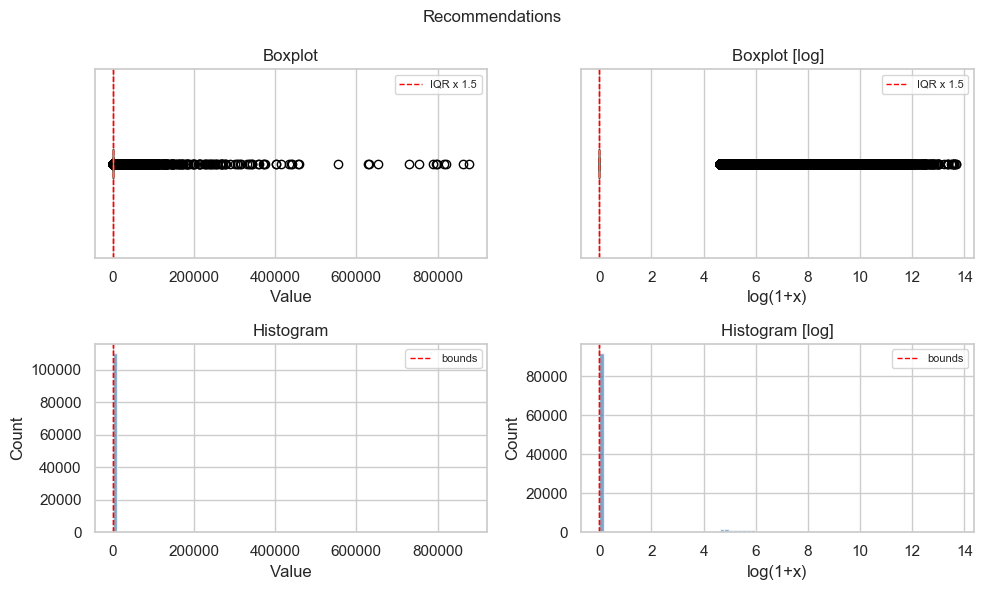

[Recommendations]  outliers: 19661 (17.63%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/878442.00  |  skew: 40.95


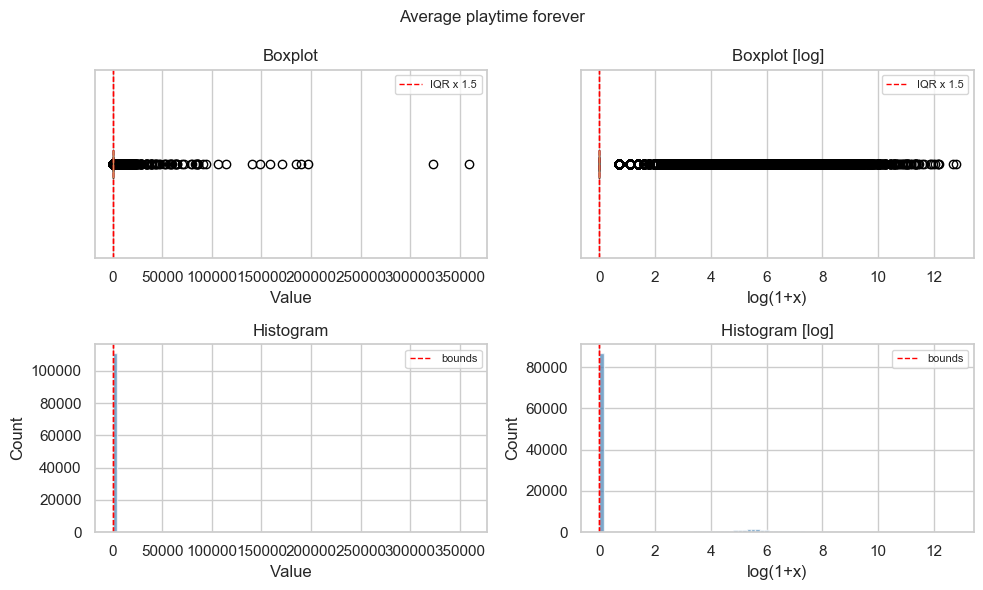

[Average playtime forever]  outliers: 24687 (22.14%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/359665.00  |  skew: 75.67


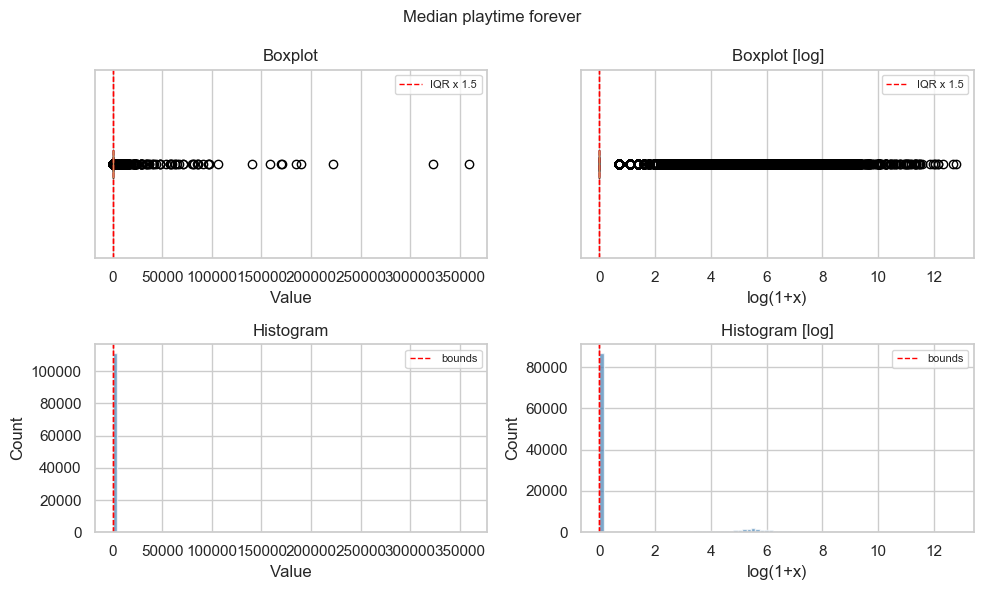

[Median playtime forever]  outliers: 24687 (22.14%)  |  bounds: [0.00, 0.00]  |  min/max: 0.00/359674.00  |  skew: 84.43


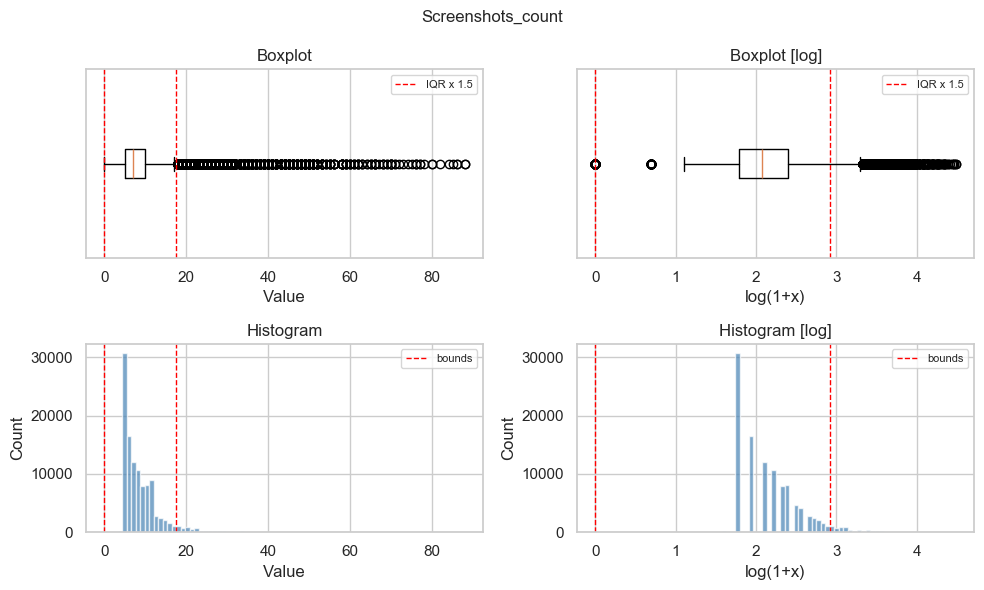

[Screenshots_count]  outliers: 6092 (5.46%)  |  bounds: [0.00, 17.50]  |  min/max: 0.00/88.00  |  skew: 3.45


,N outliers,% outliers,Lower bound,Upper bound,Skewness,Min,Max
Column,,,,,,,
release_year,507,0.45,2011.5,2031.50,-0.80,2010.0,2026.00
Required age,1141,1.02,0.0,0.00,9.97,0.0,21.00
Price,7579,6.80,0.0,13.64,12.48,0.0,199.99
Discount,0,0.00,0.0,100.00,1.13,0.0,100.00
DLC count,17127,15.36,0.0,0.00,48.27,0.0,461.00
Metacritic score,3769,3.38,0.0,0.00,5.30,0.0,97.00
User score,39,0.03,0.0,0.00,56.85,0.0,100.00
Positive,18679,16.75,0.0,102.50,54.60,0.0,2000000.00
Negative,17785,15.95,0.0,30.00,51.96,0.0,180000.00


In [896]:
analyze_all(df)

Based on the outlier analysis, I removed rows exceeding the following thresholds: 
- games released before 2010 (too few and probably completely different from todays' games), 
- price above $200, 
- DLC count above 500,
- achievements above 3,500, 
- recommendations above 1,000,000, 
- average and median playtime above 1,000,000 minutes,
- screenshot count above 100. 
These thresholds were chosen manually based on the distributions observed in the plots- values beyond these points are either data errors or extreme outliers that would disproportionately skew the analysis.

For positive and negative review counts, instead of removing the rows, I applied clipping at 2,000,000 and 180,000 respectively- preserving the games in the dataset while limiting the influence of extreme values.

In [897]:
df = df[df['release_year'] >= 2010]
df = df[df['Price'] <= 200]
df = df[df['DLC count'] <= 500]
df = df[df['Achievements'] <= 3500]
df = df[df['Recommendations'] <= 1e6]
df = df[df['Average playtime forever'] <= 1e6]
df = df[df['Median playtime forever'] <= 1e6]
df = df[df['Screenshots_count'] <= 100]

df['Positive'] = df['Positive'].clip(upper=2e6)
df['Negative'] = df['Negative'].clip(upper=0.18e6)

## ML model

In this section, I will define a new target variable called is_hit and build and train a machine learning classifier that can predict whether a game will become a hit. A game is classified as a "hit" if it meets two criteria: it has at least 1,000 positive reviews and a positive rating of 80% or higher.

In [900]:
df

,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,lang_count,audio_count,release_year,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
496350,9.210440,0,5.24,65,0,1,0,0,0,0,252,3,0,231,8,8,1,1,1,0,1,10,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1626.0,37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2016,0,0,0,0,0,1,0,0,0,0,0
1034400,9.210440,0,4.99,0,0,1,1,0,0,0,21,3,0,0,0,0,1,1,1,0,1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1178.0,33,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,2019,0,0,0,1,0,0,0,0,0,0,0
3292190,9.210440,0,8.99,0,1,1,0,0,0,0,0,0,19,0,0,0,1,0,0,0,1,7,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1827.0,27,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,2024,0,0,0,0,0,0,0,0,1,0,0
3631080,9.210440,0,4.99,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,6,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1483.0,13,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,2025,0,0,1,0,0,0,0,0,0,0,0
1654170,9.210440,0,13.99,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,5,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1834.0,8,1,1,1,1,1,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,9,2,2023,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,6.908755,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,5,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,1,0,0,0,518.0,4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,2026,0,0,0,0,0,0,0,0,0,0,0
4042800,6.908755,0,0.00,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,8,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,3335.0,30,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,3,2,2026,0,0,0,0,0,0,0,0,0,0,0
3522550,6.908755,0,7.99,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,1,5,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1376.0,15,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,2026,0,0,0,0,0,0,0,0,0,0,0
3680350,6.908755,0,2.09,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,15,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1032.0,18,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,2,2,2026,0,0,0,0,0,0,0,0,0,0,0


In [901]:
df.keys()

Index(['Estimated owners', 'Required age', 'Price', 'Discount', 'DLC count',
       'Windows', 'Mac', 'Linux', 'Metacritic score', 'User score', 'Positive',
       'Negative', 'Achievements', 'Recommendations',
       'Average playtime forever', 'Median playtime forever',
       'has_support_email', 'has_support_url', 'has_website', 'has_reviews',
       'has_header_image', 'Screenshots_count', 'is_top_developer',
       'is_top_publisher', 'has_multiplayer', 'has_local_multi',
       'has_workshop', 'has_achievements', 'has_controller_support',
       'has_cloud_saves', 'has_vr', 'has_accessibility_opts', 'has_iap',
       'genre_action', 'genre_rpg', 'genre_strategy', 'genre_sim_mgmt',
       'genre_casual_puzzle', 'genre_rogue', 'genre_adventure',
       'genre_visual_novel', 'genre_horror', 'genre_adult', 'about_length',
       'name_length', 'lang_English', 'lang_French', 'lang_German',
       'lang_Italian', 'lang_Spanish', 'lang_Chinese', 'lang_Japanese',
       'lang_Korean', '

In [903]:
total = df['Positive'] + df['Negative']
df['positive_ratio'] = df['Positive'] / total

df['is_hit'] = (
    (df['Positive'] >= 1000) & 
    (df['positive_ratio'] >= 0.8)
).astype(int)

print(df['is_hit'].value_counts())
print(f"Hit rate: {df['is_hit'].mean()*100:.1f}%")

is_hit
0    107198
1      4324
Name: count, dtype: int64
Hit rate: 3.9%


In [904]:
df[df['is_hit'] == 1]

,Estimated owners,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,has_support_email,has_support_url,has_website,has_reviews,has_header_image,Screenshots_count,is_top_developer,is_top_publisher,has_multiplayer,has_local_multi,has_workshop,has_achievements,has_controller_support,has_cloud_saves,has_vr,has_accessibility_opts,has_iap,genre_action,genre_rpg,genre_strategy,genre_sim_mgmt,genre_casual_puzzle,genre_rogue,genre_adventure,genre_visual_novel,genre_horror,genre_adult,about_length,name_length,lang_English,lang_French,lang_German,lang_Italian,lang_Spanish,lang_Chinese,lang_Japanese,lang_Korean,lang_Russian,lang_Portuguese,lang_Polish,has_audio_English,has_audio_French,has_audio_German,has_audio_Italian,has_audio_Spanish,has_audio_Chinese,has_audio_Japanese,has_audio_Korean,has_audio_Russian,has_audio_Portuguese,has_audio_Polish,lang_count,audio_count,release_year,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,positive_ratio,is_hit
1025440,11.918397,0,13.99,0,4,1,0,0,80,0,1025,210,77,994,489,52,1,1,1,1,1,9,0,0,1,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,3578.0,18,1,1,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,2019,0,0,0,0,0,0,0,1,0,0,0,0.829960,1
688420,13.527830,0,2.99,80,1,1,1,0,0,0,11367,831,11,11250,342,173,0,1,1,1,1,12,0,0,0,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,2038.0,25,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,11,0,2018,0,0,0,0,0,0,0,0,0,1,0,0.931874,1
1110050,12.765691,0,1.39,0,1,1,1,0,75,0,1637,230,17,977,205,250,1,1,1,1,1,10,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1137.0,14,1,1,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,9,0,2020,0,0,0,0,1,0,0,0,0,0,0,0.876808,1
715560,11.918397,0,9.99,0,1,1,0,0,78,0,4608,549,18,4928,320,151,1,1,1,0,1,25,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,718.0,9,1,1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,5,2,2019,1,0,0,0,0,0,0,0,0,0,0,0.893543,1
1555110,11.918397,0,1.59,0,3,1,1,1,0,0,3624,297,30,3902,91,87,1,0,0,0,1,10,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1219.0,37,1,0,1,0,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,7,0,2021,0,0,0,0,0,0,1,0,0,0,0,0.924254,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676820,12.765691,0,2.99,50,0,1,1,0,83,0,1787,102,13,1481,122,146,1,0,1,1,1,9,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1853.0,19,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2017,0,0,0,0,0,0,1,0,0,0,0,0.946003,1
268650,12.765691,0,9.99,60,2,1,1,1,0,0,10558,1305,53,10665,5222,523,1,1,1,0,1,24,0,0,1,0,1,1,1,0,0,1,0,1,0,1,1,0,0,1,0,0,0,3391.0,15,1,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,4,2,2020,0,0,0,0,0,0,0,0,0,1,0,0.889994,1
2166060,12.765691,0,3.59,60,0,1,0,0,0,0,5993,391,19,5667,161,143,1,1,0,0,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1524.0,21,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,12,2,2023,0,0,1,0,0,0,0,0,0,0,0,0.938753,1
235900,12.765691,0,2.49,90,0,1,0,0,0,0,1653,102,0,1123,3864,23,0,1,1,0,1,5,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1365.0,12,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2013,0,0,0,0,0,0,0,0,0,0,1,0.941880,1


I created two new features, that I think, will be useful for the model:
- Feature 1: DLC per year- it captures how actively the developer is supporting the game over time- which tends to correlate with a dedicated player base and a more engaged community- better chances of a game being a hit.
- Feature 2: Support quality score- it depicts how seriously a developer takes their product.

In [905]:
df['dlc_per_year'] = df['DLC count'] / (2026 - df['release_year']).clip(lower=1)
df['support_score'] = (
    df['has_website'] +
    df['has_support_email'] +
    df['has_support_url'] +
    df['has_header_image'] +
    df['has_reviews']
)

As a next step I will exclude a small set of columns for two distinct reasons.
- Direct leakage - columns that define is_hit or are computed from the same raw signals that define it. Including them would let the model "see the answer" during training, making accuracy meaningless: Positive, Negative and positive_ratio.
- Post-release metrics - they reflect critic and user reception after the game is already out. While they don't directly define is_hit, including them would give the model information that isn't available at the time a publisher needs to make an investment decision. We treat this as a pre-release prediction problem.

Everything else is fair game - playtime, price, genre, language support, developer track record, release timing, and so on. These are all signals a publisher could realistically observe or estimate before knowing whether a game will become a hit.

In [908]:
EXCLUDE = ['is_hit', 'Positive', 'Negative', 'positive_ratio', 'Recommendations', 'User score', 'Metacritic score']

feature_cols = [c for c in df.columns if c not in EXCLUDE]
X = df[feature_cols].fillna(0)
y = df['is_hit']

In [909]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111522 entries, 496350 to 4141790
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Estimated owners          111522 non-null  float64
 1   Required age              111522 non-null  int64  
 2   Price                     111522 non-null  float64
 3   Discount                  111522 non-null  int64  
 4   DLC count                 111522 non-null  int64  
 5   Windows                   111522 non-null  int64  
 6   Mac                       111522 non-null  int64  
 7   Linux                     111522 non-null  int64  
 8   Achievements              111522 non-null  int64  
 9   Average playtime forever  111522 non-null  int64  
 10  Median playtime forever   111522 non-null  int64  
 11  has_support_email         111522 non-null  int64  
 12  has_support_url           111522 non-null  int64  
 13  has_website               111522 non-null  

In [910]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [911]:
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Hit rate train: {y_train.mean()*100:.1f}%")
print(f"Hit rate test:  {y_test.mean()*100:.1f}%")

Train: (89217, 78), Test: (22305, 78)
Hit rate train: 3.9%
Hit rate test:  3.9%


### Model selection

I will compare three models.
1. Logistic Regression- a simple baseline. Fast, interpretable, and easy to explain.
2. Random Forest- builds many decision trees and combines their results. Handles messy, non-linear data well and tells us which features matter most.
3. XGBoost- similar idea to Random Forest but builds trees sequentially, each one correcting the mistakes of the previous. Usually the strongest performer on tabular data and our main candidate here.

All three support class_weight / scale_pos_weight to handle the fact that only ~4% of games are hits, so the model doesn't just learn to predict "not a hit" every time.

### Metrics and Cross-Validation

To evaluate the model's performance accurately, I used Stratified K-Fold Cross-Validation.

This method was chosen because the dataset is highly imbalanced, with the positive class representing only 3.8% of the data. Unlike standard cross-validation, the "Stratified" approach ensures that each fold maintains the same percentage of positive cases as the original dataset. This prevents situations where a fold might contain no positive examples, which would lead to unreliable results.

I've decided to calculate the models performance on following metrics:
1. F1- harmonic mean of precision and recall that penalizes models that sacrifice either one to game the score. A model that calls everything "not a hit" to avoid mistakes, or one that calls everything "a hit" to catch them all, will both score poorly.
2. ROC-AUC- measures how well the model separates hits from non-hits across all decision thresholds and is unaffected by class imbalance.  Useful for comparing models independently.
3. Precision- says, of all games predicted as hits, how many actually are. In the context of our problem this translates to: how often can we trust the model's recommendation to invest?
4. Recall- of all actual hits, how many did the model catch. Low recall means we're systematically missing games that would have succeeded passing on opportunities that were right in front of us.

Accuracy is intentionally excluded- a model predicting 'not hit' every time would score 96.2%, making it a misleading and useless metric here.

In [679]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [917]:
def print_cv_results(name, cv_results):
    print(f"\n{'─'*35}")
    print(f"  {name}")
    print(f"{'─'*35}")
    for metric in ['f1', 'roc_auc', 'precision', 'recall']:
        train_score = cv_results[f'train_{metric}'].mean()
        val_score   = cv_results[f'test_{metric}'].mean()
        print(f"  {metric:12s}  train: {train_score:.3f}  val: {val_score:.3f}")
    print(f"{'─'*35}")

In [ ]:
def evaluate_model(name, model, X_test, y_test, y_pred=None, y_proba=None):
    if y_pred is None:
        y_pred = model.predict(X_test)
    if y_proba is None:
        y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
    }

    print(f"\n{'─'*35}")
    print(f"  {name}")
    print(f"{'─'*35}")
    for metric, value in metrics.items():
        print(f"  {metric:<12} {value:.3f}")
    print(f"{'─'*35}")

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['not hit', 'hit'], fontsize=11)
    ax.set_yticklabels(['not hit', 'hit'], fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'Confusion Matrix - {name}', fontsize=12)

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}',
                    ha='center', va='center', fontsize=13,
                    color='white' if cm[i, j] > thresh else 'black',
                    fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    return metrics

### Model 1 (baseline)- Logistic regression

In [912]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [913]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

In [914]:
cv_results = cross_validate(
    lr, X_train_scaled, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=True
)

In [918]:
print_cv_results("Logistic Regression", cv_results)


───────────────────────────────────
  Logistic Regression
───────────────────────────────────
  f1            train: 0.515  val: 0.512
  roc_auc       train: 0.979  val: 0.978
  precision     train: 0.354  val: 0.351
  recall        train: 0.948  val: 0.942
───────────────────────────────────



───────────────────────────────────
  Logistic Regression
───────────────────────────────────
  F1           0.503
  ROC-AUC      0.979
  Precision    0.344
  Recall       0.938
───────────────────────────────────


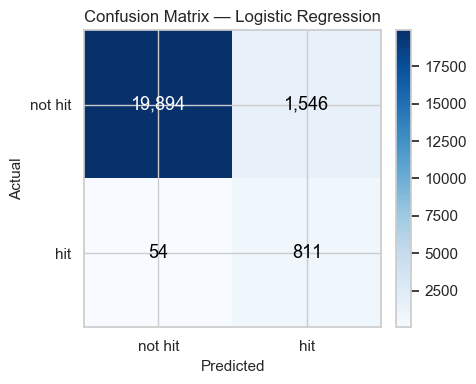

In [916]:
lr.fit(X_train_scaled, y_train)
results_lr = evaluate_model("Logistic Regression", lr, X_test_scaled, y_test)

The model shows no signs of overfitting- train and validation scores are nearly identical across all metrics, which is reassuring.
ROC-AUC of 0.979 is excellent, meaning the model is very good at ranking hits above non-hits. However, the low Precision (0.344) tells that only 1 in 3 games flagged as a hit actually is one. Recall is high (0.938)- it catches almost all real hits, but at the cost of many false positives. Overall, I think it is a decent baseline - but the poor Precision limits its practical usefulness. I expect tree-based models to improve on this.

### Model 2- Random forest

In [919]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [920]:
cv_results_rf = cross_validate(
    rf, X_train, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=True
)

In [921]:
print_cv_results("Random Forest", cv_results_rf)


───────────────────────────────────
  Random Forest
───────────────────────────────────
  f1            train: 1.000  val: 0.513
  roc_auc       train: 1.000  val: 0.984
  precision     train: 1.000  val: 0.765
  recall        train: 1.000  val: 0.387
───────────────────────────────────



───────────────────────────────────
  Random Forest
───────────────────────────────────
  F1           0.512
  ROC-AUC      0.985
  Precision    0.752
  Recall       0.388
───────────────────────────────────


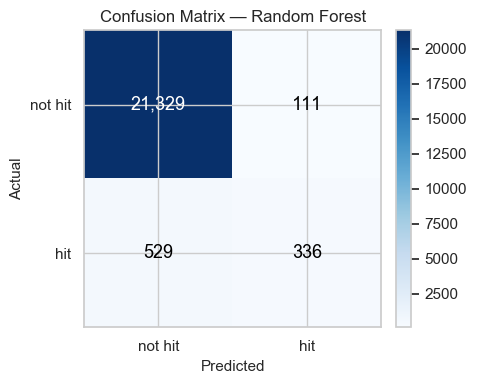

In [922]:
results_rf  = evaluate_model("Random Forest", rf, X_test, y_test)

The Random Forest revealed an overfitting problem: perfect scores on training data (F1=1.000, Precision=1.000, Recall=1.000) but much weaker validation performance (F1=0.513). Model memorized the training set rather than learning general patterns.

Hyperparameter tuning using ReandomizedSearchCV was applied to address this.

In [931]:
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.3],
}

In [933]:
rf_tuned = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=30,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [934]:
rf_tuned.fit(X_train, y_train)

print("Best params:", rf_tuned.best_params_)
print(f"Best F1 (CV): {rf_tuned.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.3, 'max_depth': 30}
Best F1 (CV): 0.685


In [939]:
cv_results_rf_tuned = cross_validate(
    rf_tuned.best_estimator_, X_train, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=True
)
print_cv_results("Random Forest (tuned)", cv_results_rf_tuned)


───────────────────────────────────
  Random Forest (tuned)
───────────────────────────────────
  f1            train: 0.844  val: 0.685
  roc_auc       train: 0.999  val: 0.986
  precision     train: 0.730  val: 0.592
  recall        train: 1.000  val: 0.811
───────────────────────────────────



───────────────────────────────────
  Random Forest (tuned)
───────────────────────────────────
  F1           0.685
  ROC-AUC      0.986
  Precision    0.588
  Recall       0.820
───────────────────────────────────


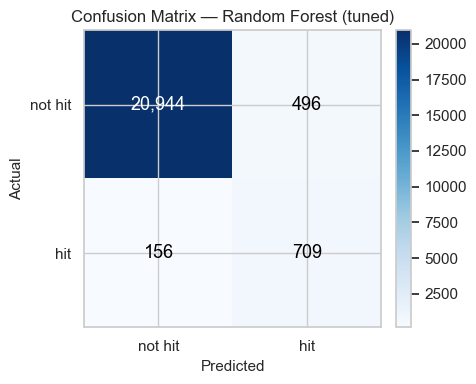

In [940]:
results_rf_tuned = evaluate_model("Random Forest (tuned)", rf_tuned.best_estimator_, X_test, y_test)

After hyperparameter tuning the results of RandomForest improved. Train/val gap shrinked- a sign that regularization successfully reduced overfitting. F1 score and recall improved a lot.

Compared to Logistic Regression, the tuned Random Forest performs much better: Precision rises from 0.344 to 0.588, meaning fewer false alarms. Recall drops from 0.938 to 0.820. ROC-AUC stayed similarly high (0.986 vs 0.979).

### Model 3- XGBoost

In [941]:
X_train_xgb = X_train.values.astype(float)
X_test_xgb  = X_test.values.astype(float)

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train_xgb, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [942]:
cv_results_xgb = cross_validate(
    xgb, X_train_xgb, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=True
)
print_cv_results("XGBoost", cv_results_xgb)


───────────────────────────────────
  XGBoost
───────────────────────────────────
  f1            train: 0.856  val: 0.667
  roc_auc       train: 1.000  val: 0.983
  precision     train: 0.749  val: 0.556
  recall        train: 1.000  val: 0.834
───────────────────────────────────



───────────────────────────────────
  XGBoost
───────────────────────────────────
  F1           0.675
  ROC-AUC      0.985
  Precision    0.551
  Recall       0.872
───────────────────────────────────


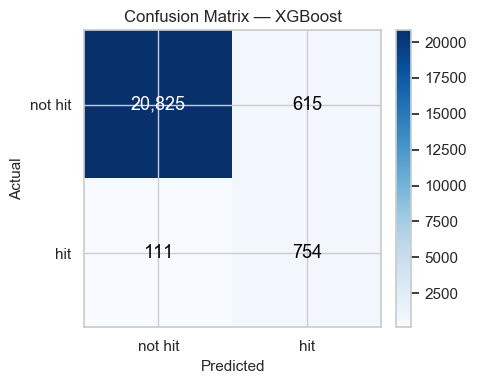

In [947]:
results_xgb = evaluate_model("XGBoost", xgb, X_test_xgb, y_test)

Similar to the Random Forest model, we observe clear signs of overfitting. I will now perform hyperparameter tuning here, to address this problem.

In [951]:
param_dist_xgb = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.01, 0.05],
    'subsample':        [0.6, 0.7],
    'colsample_bytree': [0.6, 0.7],
    'min_child_weight': [5, 10, 20],
    'gamma':            [0.3, 0.5, 1.0],
}

In [952]:
xgb_tuned = RandomizedSearchCV(
    xgb,
    param_dist_xgb,
    n_iter=30,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [953]:
xgb_tuned.fit(X_train_xgb, y_train)

print("Best params:", xgb_tuned.best_params_)
print(f"Best F1 (CV): {xgb_tuned.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 1.0, 'colsample_bytree': 0.7}
Best F1 (CV): 0.612


In [954]:
cv_results_xgb_tuned = cross_validate(
    xgb_tuned.best_estimator_, X_train_xgb, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=True
)
print_cv_results("XGBoost (tuned)", cv_results_xgb_tuned)


───────────────────────────────────
  XGBoost (tuned)
───────────────────────────────────
  f1            train: 0.654  val: 0.612
  roc_auc       train: 0.995  val: 0.987
  precision     train: 0.486  val: 0.454
  recall        train: 0.998  val: 0.938
───────────────────────────────────



───────────────────────────────────
  XGBoost (tuned)
───────────────────────────────────
  F1           0.604
  ROC-AUC      0.987
  Precision    0.443
  Recall       0.949
───────────────────────────────────


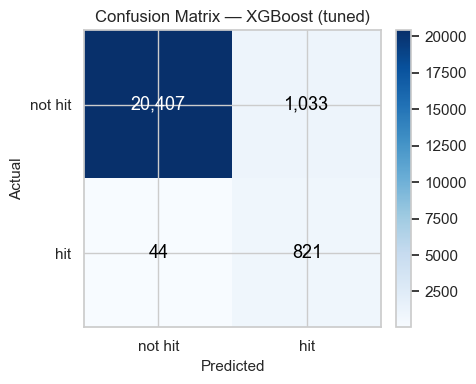

In [955]:
results_xgb_tuned = evaluate_model("XGBoost (tuned)", xgb_tuned.best_estimator_, X_test_xgb, y_test)

The overfitting problem is now resolved- train and validation scores are much closer than before (F1: 0.654 train vs 0.612 val). The model is. However, Recall is extremely high (0.949) but Precision collapsed to 0.443. This means the model catches nearly every real hit, but flags more than half of its predictions incorrectly.

Compared to the tuned Random Forest (F1: 0.685, Precision: 0.588, Recall: 0.820), this XGBoost version is weaker overall. It catches more hits (0.949 vs 0.820) but generates far too many false alarms to be practically useful.


───────────────────────────────────
  XGBoost (threshold=0.0)
───────────────────────────────────
  F1           0.704
  ROC-AUC      0.987
  Precision    0.651
  Recall       0.766
───────────────────────────────────


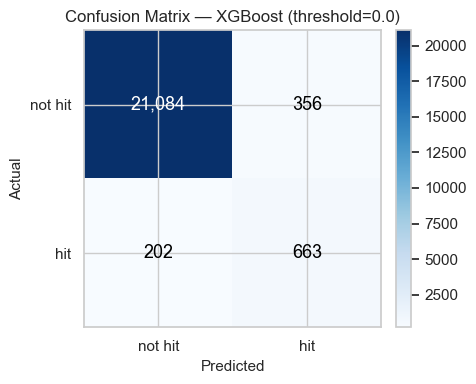

{'F1': 0.7038216560509554,
 'ROC-AUC': 0.9874672698645499,
 'Precision': 0.6506378802747792,
 'Recall': 0.7664739884393064}

In [960]:
y_proba_xgb = xgb_tuned.best_estimator_.predict_proba(X_test_xgb)[:, 1]
y_pred_xgb_thresh = (y_proba_xgb >= 0.9).astype(int)

evaluate_model("XGBoost (threshold=0.0)", xgb_tuned.best_estimator_,
               X_test_xgb, y_test,
               y_pred=y_pred_xgb_thresh, y_proba=y_proba_xgb)

I tried experimenting with adjusting the classification threshold. By default, the model predicts "hit" for any probability above 0.5. Based on previous results, I raised this threshold to 0.9, which means the model only commits to a "hit" prediction when it is very confident.

The results are surprisingly strong. F1 jumped to 0.704- the best score across all models so far- with a nice balance between Precision (0.651) and Recall (0.766). Turns out that maybe the problem was never the model itself, but the default decision boundary for the given heavy class imbalance.

### Feature importance

In [ ]:
def plot_feature_importance(name, model, feature_names, top_n=30):
    
    if hasattr(model, 'coef_'):
        importance = np.abs(model.coef_[0])
    elif hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    else:
        return

    indices = np.argsort(importance)[-top_n:]
    
    fig, ax = plt.subplots(figsize=(8, top_n * 0.4))
    ax.barh(range(top_n), importance[indices], color='steelblue')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} features - {name}')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

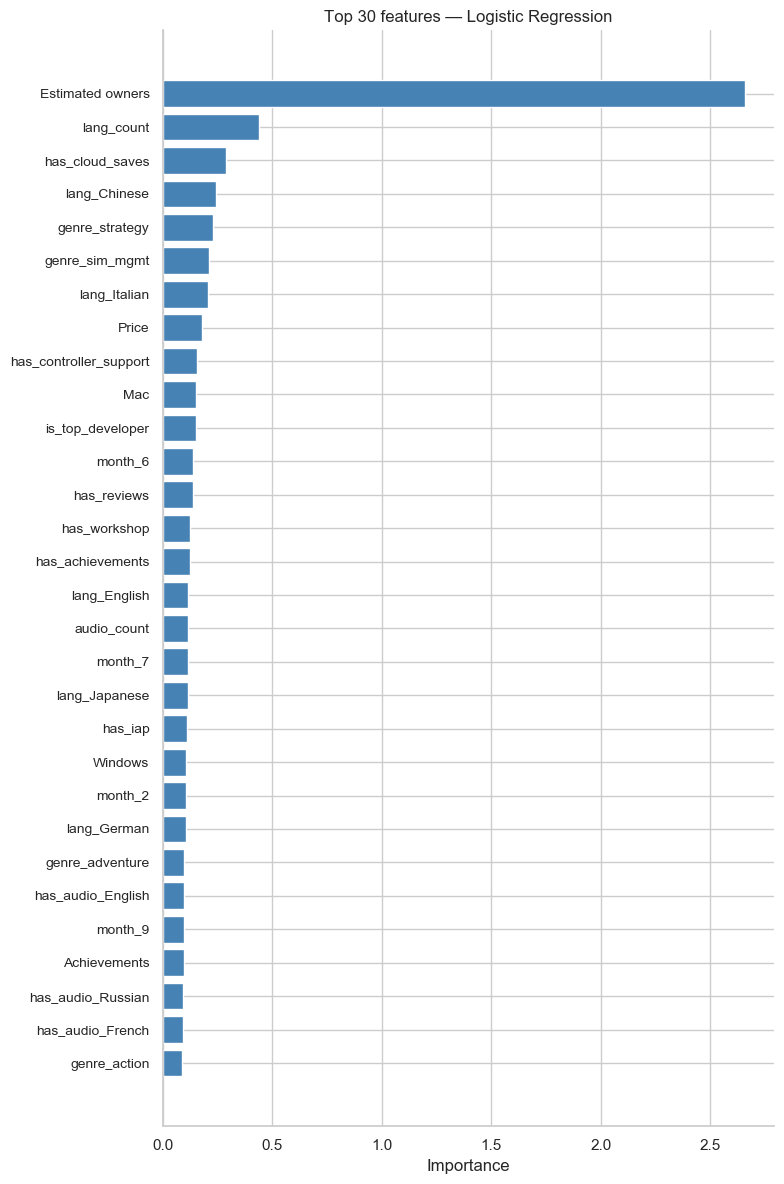

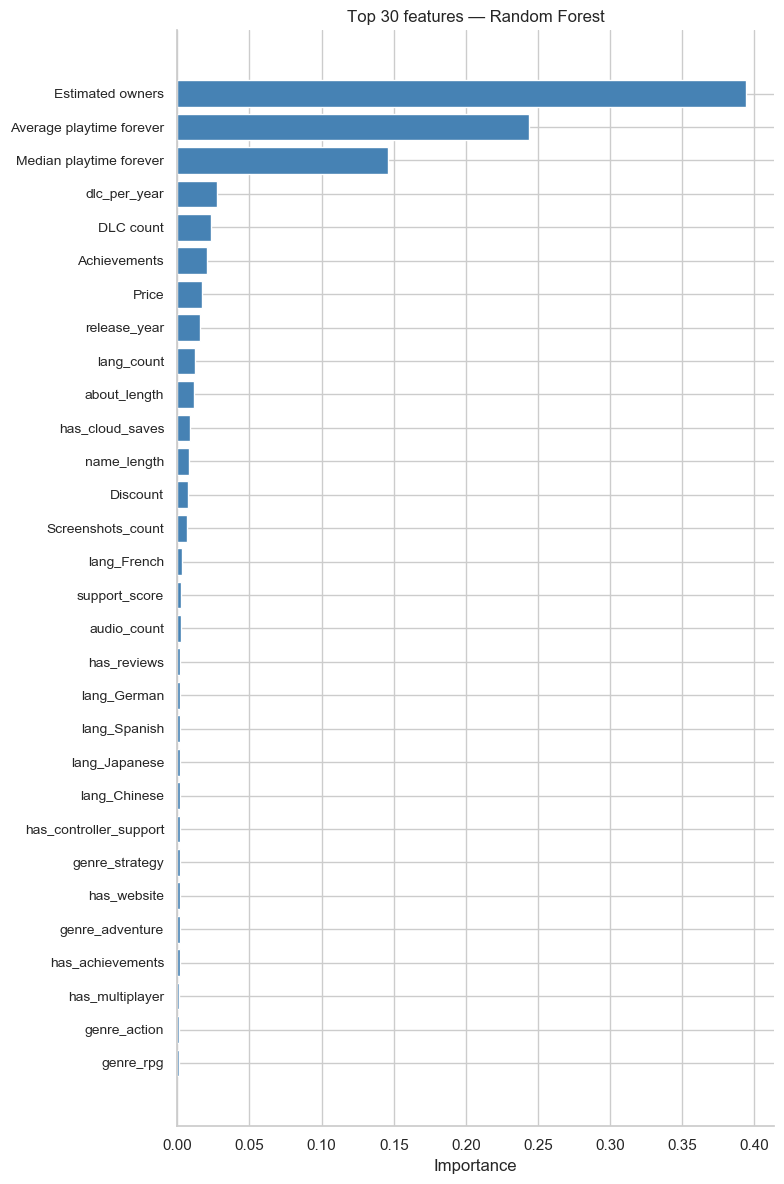

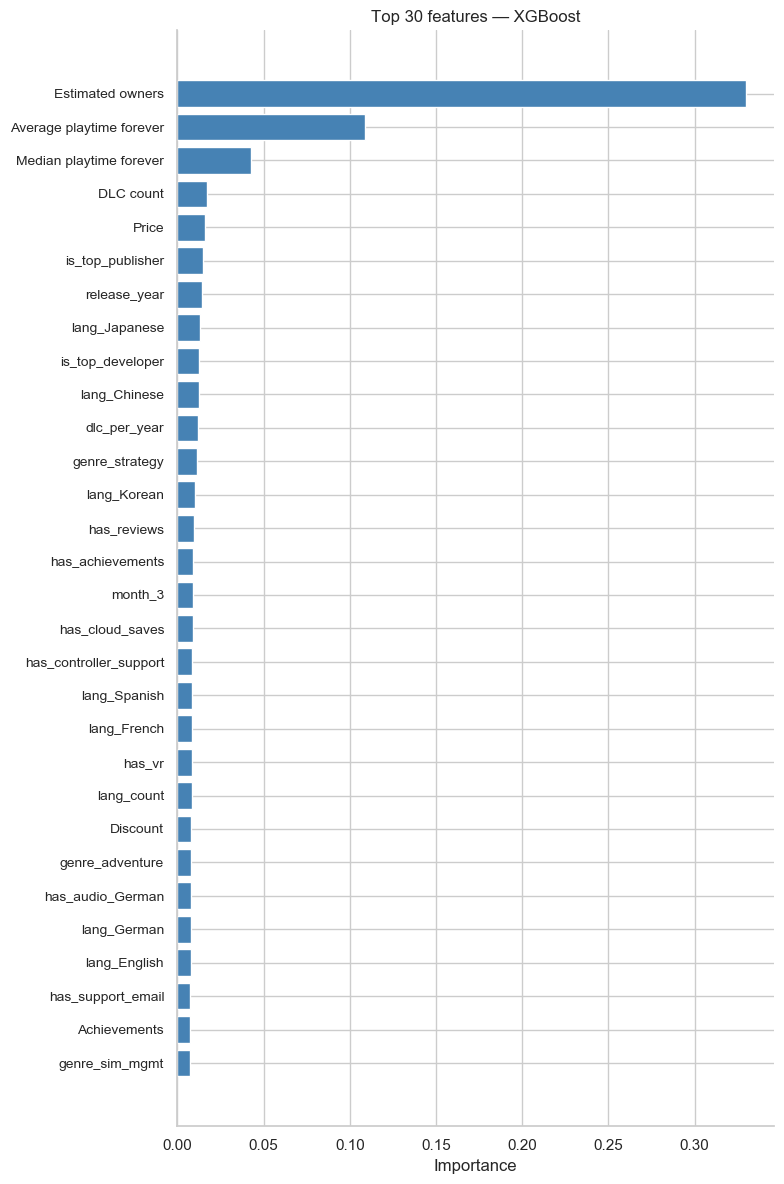

In [962]:
feature_names = list(X_train.columns)

plot_feature_importance("Logistic Regression", lr, feature_names)
plot_feature_importance("Random Forest", rf_tuned.best_estimator_, feature_names)
plot_feature_importance("XGBoost", xgb_tuned.best_estimator_, feature_names)

Estimated owners dominated all three models as the most important feature, which makes sense- a game with more owners has simply had more chances to accumulate reviews and reach the hit threshold.

Average and Median playtime were the next most important features in both Random Forest and XGBoost. This is also intuitive- players who enjoy a game play it longer, give reviews, recommend it to others etc.

The third most important feature for LogisticRegression, has_cloud_saves, seems interesting- I would have not guessed it as something that important. And it appears quite low in the charts for other models.

Beyond the top three, a few things stand out. DLC count and dlc_per_year appeared consistently - active post-release support seems to matter. Language features (lang_Chinese, lang_Japanese, lang_Korean) showed up across all models, suggesting that games available in Asian market localization tend to do better.

## Questions

### a) Difference of results on test and train data

That difference is called Overfitting. It happens, when the model memorizes the training data including its random noise, instead of learning general patterns.
When it sees new data, those memorized details don't transfer- the model does not generalize on new data and fails.
It happend earlier in this report for the untuned Random Forest, which scored 1.000 on training but only 0.513 F1 on validation.

Two ways to fix it:
1. Cross-validation - instead of using one fixed  data split we rotate the data through multiple "folds". This gives a more honest picture of real performance and exposes overfitting clearer.
2. Regularization - limiting how complex the model can get. A simpler model can't memorize the training data as easily, so it generalizes better to new examples.

### b) Dealing with imbalanced classes

The main problems that heavy class imbalance causes are:
- A model that predicts "not a hit" every time scores 96.2% accuracy, making accuracy a completely useless metric- on the real data such model will never predict a hit.
- Models tend to ignore the minority class entirely, as they try to minimize total error. Because hits are so rare, the model can "ignore" them to keep the total error low. This way successfull games become random noise.
- Poor Generalization: because there are so few "hits," the model draws a very tight decision boundary around them. This means the model becomes too strict and fails to recognize new successful games that look even slightly different from the ones in the training set.

There are a few strategies, that help address this problem:

Stratedy 1.  Balancing class weights
This tells the model to treat each hit as ~24x (hit to non hit ratio) more important than a non-hit during training. The data itself doesn't change- only how much the model penalizes mistakes on the minority class.

The difference is visible when comparing the performance of Random Forest on our data with and without it:
- No weight: F1: 0.601, Precision: 0.750, Recall: 0.501
- Balanced: F1: 0.685, Precision: 0.588, Recall: 0.820

Without balancing, the model is precise but misses half of all real hits (Recall 0.501). It is only predicting "hit" when very confident.
With class_weight='balanced', Recall jumps to 0.820. The trade-off is lower Precision (0.588), meaning more false positives. But overall F1 improves from 0.601 to 0.685, making the balanced version the better choice for this problem.


Strategy 2. threshold tuning
Instead of modifying the training process, the decision boundary can be adjusted at prediction time. By default, the model predicts "hit" for any probability above 0.5. Raising it forces the model to only commit to a prediction when it's very confident.

I tried changing that treshold for XGBoost here- from 0.5 to 0.9. It improved F1 from 0.604 to 0.704 and raised Precision from 0.443 to 0.651 while keeping Recall at 0.766. This is a much more useful balance for a real publisher.

A third common strategy worth mentioning is SMOTE, which generates synthetic examples of the minority class to balance the training set. With ~4700 real hits available, SMOTE could provide additional signal, make this class more significant. However, with such a large imbalance ratio, there is a risk of generating unrealistic synthetic examples that don't reflect real patterns in the data, which is why I have not applied this method here.


───────────────────────────────────
  Random Forest (no class_weight)
───────────────────────────────────
  F1           0.601
  ROC-AUC      0.985
  Precision    0.750
  Recall       0.501
───────────────────────────────────


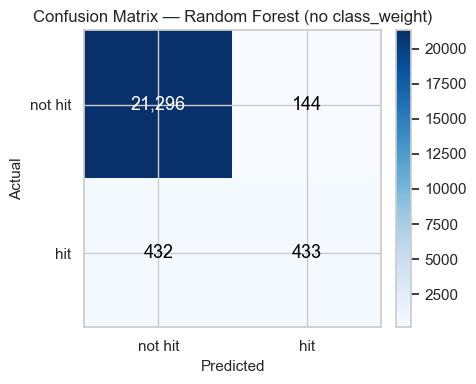

{'F1': 0.6005547850208044,
 'ROC-AUC': 0.9847735311879906,
 'Precision': 0.7504332755632582,
 'Recall': 0.500578034682081}

In [963]:
rf_no_weight = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_no_weight.fit(X_train, y_train)
evaluate_model("Random Forest (no class_weight)", rf_no_weight, X_test, y_test)

### c) Precision vs. recall- the publisher’s perspective

I think that the answer for the question "Is high precision or high recall more important for the publisher deciding on investment?" depends on the size of the publisher.

For a small publisher with a limited budget, precision is more important. Every bad investment costs directly, while a lost opportunity does not. They need the model to be selective and confident before recommending an investment.

For a large publisher with a big budget, recall becomes more valuable. They can afford to invest some in games that won't succeed as long as they don't miss the next big thing.

## Conclusions

The biggest challenge was undoubtedly the dataset itself. With 39 columns and over 100,000 rows, it was challengig to decide- which columns to drop, how to handle missing values, what to do with outliers, and how to encode descriptive fields into something a model can actually use. There were no obvious right answers, and every choice decision required careful, as it had consequences further down the pipeline.

The most interesting part for me was exploring the data before modeling, finding unexpected patterns- like the relationship between game name length or description length and the number of reviews was genuinely surprising.

A really valuable lesson was the huge class imbalance in data. 3.8% positive class sounds like a small detail, but it really shapes the way how modeling should be approached- which metrics to use, how to train the models, and how to interpret the results.

Finally, this project taught me mainy, how important it is, and simultaneously- how hard it is, to understand the data well enough to make good decisions before you ever write a line of modeling code.